# Measuring the Unmeasurable: A 2026 World Cup Readiness Framework

**Team XOH — Soomi Oh, Yoo Mi Oh**  
**GT OMSA Capstone · April 2026**

---

## Overview

The 2026 FIFA World Cup is the most complex edition of the tournament ever staged. Forty-eight nations. Three host confederations. A genuinely open competitive field. And — as always — an enormous industry of predictions, most of which quietly ignore the question underneath all the others: *how do you actually measure a national team's readiness before a ball is kicked?*

This notebook documents our attempt to answer that question using StatsBomb open data. The central argument is not that we can predict the winner. It is something more useful and, we think, more honest: that readiness is a multi-layered construct that requires distinct measurement tools for each layer — and that each of those tools has a failure mode worth understanding.

We built a three-layer framework:

| Layer | What it measures | Data source |
|---|---|---|
| **Tactical identity** | *How* a team plays — collective patterns under pressure | StatsBomb tournament data 2022–2024 |
| **Player quality** | *Who* plays — individual performance above position baseline | StatsBomb club data 2021/22–2023/24 |
| **Readiness score** | *How ready* — composite of quality, style, context, uncertainty | All of the above + FIFA rankings, Guardian 100 |

The contribution is not a ranked list. It is the framework: the design decisions that had to be made, the places where the data pushed back, and what the measurement limitations tell us about the game itself.

> **A note on scope:** All analysis uses StatsBomb open data. Player scoring covers club seasons 2021/22–2023/24. Tactical clustering covers WC 2022, Euro 2024, Copa América 2024, and AFCON 2023. We do not have complete data for all 48 qualified nations, and we are explicit about where that gap affects conclusions.


---
## Setup

In [1]:
%config InlineBackend.figure_format = 'retina'

import sys
import warnings
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

# ── Path setup ───────────────────────────────────────────────────────────────
NOTEBOOK_DIR  = Path(".").resolve()
PROJECT_ROOT  = NOTEBOOK_DIR.parent
EDA_ROOT      = PROJECT_ROOT / "eda"

for p in [str(PROJECT_ROOT),
          str(PROJECT_ROOT / "player_score"),
          str(PROJECT_ROOT / "composite_score"),
          str(PROJECT_ROOT / "tactical_clustering"),
          str(EDA_ROOT)]:
    if p not in sys.path:
        sys.path.insert(0, p)

FIGURES_DIR = NOTEBOOK_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

# ── Shared style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":        150,
    "figure.facecolor":  "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.25,
    "grid.linestyle":    "--",
    "font.family":       "sans-serif",
    "axes.titlesize":    12,
    "axes.titleweight":  "bold",
    "axes.labelsize":    10,
})

PALETTE = {
    "High Press / High Output" : "#1a6eb5",
    "Possession Dominant"      : "#5bafd6",
    "Compact Transition"       : "#27ae60",
    "Mid-Block Reactive"       : "#f39c12",
    "Moderate Possession"      : "#e67e22",
    "Low Intensity"            : "#e74c3c",
}

print("✓ Setup complete")


✓ Setup complete


---
## Section I — Tactical Identity: Clustering 71 Nations Across 8 Dimensions

The starting premise is that style of play is a measurable, stable property of national teams — not just an aesthetic description. If two teams both press high, dominate possession, and generate high expected goals, they are playing the same *type* of football, regardless of whether one is Argentina and the other is Canada.

This section asks: *how many genuinely distinct tactical identities exist in international tournament football, and which identity is each 2026 qualifier?*

To answer it, we cluster 71 national teams using eight match-level metrics derived from StatsBomb tournament data (WC 2022, Euro 2024, Copa América 2024, AFCON 2023). The clustering is not the end of the analysis — it is the input to everything that follows.

All code for this section lives in the `tactical_clustering/` module. For a detailed walkthrough of every methodological decision, including the full validation suite, see `tactical_clustering/tactical_clustering_xoh.ipynb`.


### 1.1 — The Eight Dimensions

We designed the feature set to capture independent aspects of how teams play. No two metrics measure the same thing.

| # | Metric | What it captures |
|---|---|---|
| D1 | **PPDA** *(Passes Allowed Per Defensive Action)* | Pressing intensity — lower = more aggressive |
| D2 | **Defensive line height** | How high the team defends — proxy for territorial ambition |
| D3 | **Field tilt %** | % of touches in the opponent's third — territorial dominance |
| D4 | **Possession %** | Ball retention volume |
| D5 | **Progressive carry %** | Carries as % of total progressive actions — direct vs. passing-based progression |
| D6 | **npxG per match** | Non-penalty expected goals — attacking threat quality |
| D7 | **EPR** *(Expected Points per Ranked Chance)* | Possession efficiency — how much threat per unit of possession |
| D8 | **Avg xG per buildup possession** | Build-up quality — threat generated through patient sequences |

Two additional volatility features are added at aggregation time: **PPDA std** and **possession % std**. These distinguish tactically rigid sides (Brazil, Uruguay) from high-variance adapters (Argentina, Germany) — teams that look similar on means but have fundamentally different match-to-match profiles. This distinction emerged clearly in our EDA's tactical consistency analysis.


### 1.2 — Data Loading & Aggregation

In [12]:
import importlib
import analysis.data_loader as _dl
importlib.reload(_dl)
import tc_data
importlib.reload(tc_data)
from tc_data import load_pipeline, CORE_METRICS, CLUSTER_FEATURES

metrics, team_metrics = load_pipeline(verbose=False)
print(f"Match-level data : {metrics.shape[0]:,} rows × {metrics.shape[1]} columns")
print(f"Team-level data  : {team_metrics.shape[0]} teams × {team_metrics.shape[1]} features")


Team-level shape  : (71, 12)
Teams             : 71
=== SHAPE ===
(71, 12)

=== NULL CHECK ===
shape: (1, 12)
┌──────┬──────┬──────────────┬──────────────┬───┬─────────────┬──────────┬─────────────┬───────────┐
│ team ┆ ppda ┆ defensive_li ┆ field_tilt_p ┆ … ┆ avg_xg_per_ ┆ ppda_std ┆ possession_ ┆ n_matches │
│ ---  ┆ ---  ┆ ne_height    ┆ ct           ┆   ┆ buildup_pos ┆ ---      ┆ pct_std     ┆ ---       │
│ u32  ┆ u32  ┆ ---          ┆ ---          ┆   ┆ session     ┆ u32      ┆ ---         ┆ u32       │
│      ┆      ┆ u32          ┆ u32          ┆   ┆ ---         ┆          ┆ u32         ┆           │
│      ┆      ┆              ┆              ┆   ┆ u32         ┆          ┆             ┆           │
╞══════╪══════╪══════════════╪══════════════╪═══╪═════════════╪══════════╪═════════════╪═══════════╡
│ 0    ┆ 0    ┆ 0            ┆ 0            ┆ … ┆ 0           ┆ 0        ┆ 0           ┆ 0         │
└──────┴──────┴──────────────┴──────────────┴───┴─────────────┴──────────┴───────

### 1.3 — Preprocessing: The Georgia & Slovenia Problem

Before clustering, two decisions must be made: which teams to include, and how to handle the scale differences between features.

**The outlier exclusion:**  
A data quality audit surfaced two extreme PPDA outliers:
- **Georgia:** PPDA 31.53 — more than 4 standard deviations above the dataset median
- **Slovenia:** PPDA 23.08 — more than 3 standard deviations above the median

In initial runs with k=4 through k=7, these two teams formed their own artifact cluster regardless of cap threshold. Tightening the cap enough to absorb them dragged Japan (PPDA 17.11) — a tactically meaningful outlier — into the same group. Neither Georgia nor Slovenia qualified for the 2026 World Cup. Exclusion is therefore both statistically and analytically justified.

Tanzania's extreme EPR (1,663) is handled differently — it is not excluded but absorbed by the 95th percentile cap in the next step, which brings it in line with the rest of the distribution without losing the directional signal that it is a low-efficiency possession team.

**Outlier capping:**  
After exclusion, PPDA and EPR are capped at the 95th percentile. At n=69 teams, the 99th percentile is effectively a single value. The 95th percentile pulls in 3–4 teams per feature while preserving the directional signal. All features are then scaled with `StandardScaler`.


In [13]:
import polars as pl
from tc_preprocessing import cap_and_scale

EXCLUDE_TEAMS = ["Georgia", "Slovenia"]
team_metrics_filtered = team_metrics.filter(~pl.col("team").is_in(EXCLUDE_TEAMS))

print(f"Teams before exclusion : {len(team_metrics)}")
print(f"Teams after exclusion  : {len(team_metrics_filtered)}")
print()

X, teams, scaler, cap_info = cap_and_scale(team_metrics_filtered, ppda_pct=0.95, epr_pct=0.95)


Teams before exclusion : 71
Teams after exclusion  : 69

PPDA cap (95%): 19.06  →  3 team(s) affected
EPR  cap (95%): 261.47  →  3 team(s) affected

Feature matrix shape : (69, 10)
Any NaNs             : False

Post-scaling means (should be ~0):
ppda                             0.0
defensive_line_height           -0.0
field_tilt_pct                  -0.0
possession_pct                   0.0
progressive_carry_pct           -0.0
epr                             -0.0
npxg                            -0.0
avg_xg_per_buildup_possession    0.0
ppda_std                         0.0
possession_pct_std               0.0

Post-scaling stds (should be ~1):
ppda                             1.007
defensive_line_height            1.007
field_tilt_pct                   1.007
possession_pct                   1.007
progressive_carry_pct            1.007
epr                              1.007
npxg                             1.007
avg_xg_per_buildup_possession    1.007
ppda_std                         1.00

### 1.4 — K Selection: Why Not k=4?

The choice of k is the most consequential methodological decision in the clustering analysis. We evaluated k=2 through k=9 using four independent diagnostics.

**The k=2 finding:**  
k=2 wins the composite ranking with a silhouette score of 0.294 — nearly double any other k value. This is not a modelling failure — it is the primary structural finding of the clustering analysis. **International tournament teams exist on a tactical continuum, not in discrete clusters.** The dominant axis separates high-press/high-possession sides from low-press/low-possession sides. Every subsequent k subdivides this continuum rather than revealing independent structure.

The silhouette scores across all remaining k values (0.120–0.187) confirm this: even the best analytically meaningful partition explains relatively little of the variance. This is a property of the data, not the algorithm.

**Why k=4 is insufficient:**  
Our initial analysis used k=4, which produced a single "Proactive Dominant" cluster of 16 teams spanning Argentina and Spain at the elite end down to Belgium, Mexico and Canada. A framework that assigns the same tactical profile to the world champions and a group-stage exit is analytically indefensible for a 2026 readiness framework.

**Why k=6 and not k=7:**  
k=7 marginally outperforms k=6 on Davies-Bouldin (1.462 vs 1.616) and composite rank (4.50 vs 4.75). However, k=6 produces the highest GMM ARI of any k≥4 (0.455 vs 0.347 at k=7) — meaning the six-cluster structure is substantially more reproducible under a different modelling assumption than the seven-cluster structure. For a framework where archetype assignments feed directly into the composite readiness score, reproducibility across models matters more than marginal gains on a single geometric metric. k=6 is the defensible choice on that basis.

k=2 | Sil: 0.294 | CH: 23.8 | DB: 1.441 | ARI: 0.636 | Inertia: 509.3
k=3 | Sil: 0.187 | CH: 20.4 | DB: 1.640 | ARI: 0.449 | Inertia: 426.4
k=4 | Sil: 0.158 | CH: 17.9 | DB: 1.621 | ARI: 0.336 | Inertia: 377.8
k=5 | Sil: 0.150 | CH: 15.3 | DB: 1.606 | ARI: 0.228 | Inertia: 352.6
k=6 | Sil: 0.126 | CH: 13.8 | DB: 1.616 | ARI: 0.455 | Inertia: 328.9
k=7 | Sil: 0.133 | CH: 13.0 | DB: 1.462 | ARI: 0.347 | Inertia: 305.7
k=8 | Sil: 0.120 | CH: 11.9 | DB: 1.547 | ARI: 0.382 | Inertia: 291.7
k=9 | Sil: 0.124 | CH: 11.5 | DB: 1.495 | ARI: 0.263 | Inertia: 272.1

=== K SELECTION — MULTI-METRIC DECISION MATRIX ===

 k  silhouette  calinski_harabasz  davies_bouldin  gmm_ari  avg_rank
 2       0.294               23.8           1.441    0.636      1.00
 3       0.187               20.4           1.640    0.449      3.75
 4       0.158               17.9           1.621    0.336      4.75
 5       0.150               15.3           1.606    0.228      5.25
 6       0.126               13.8         

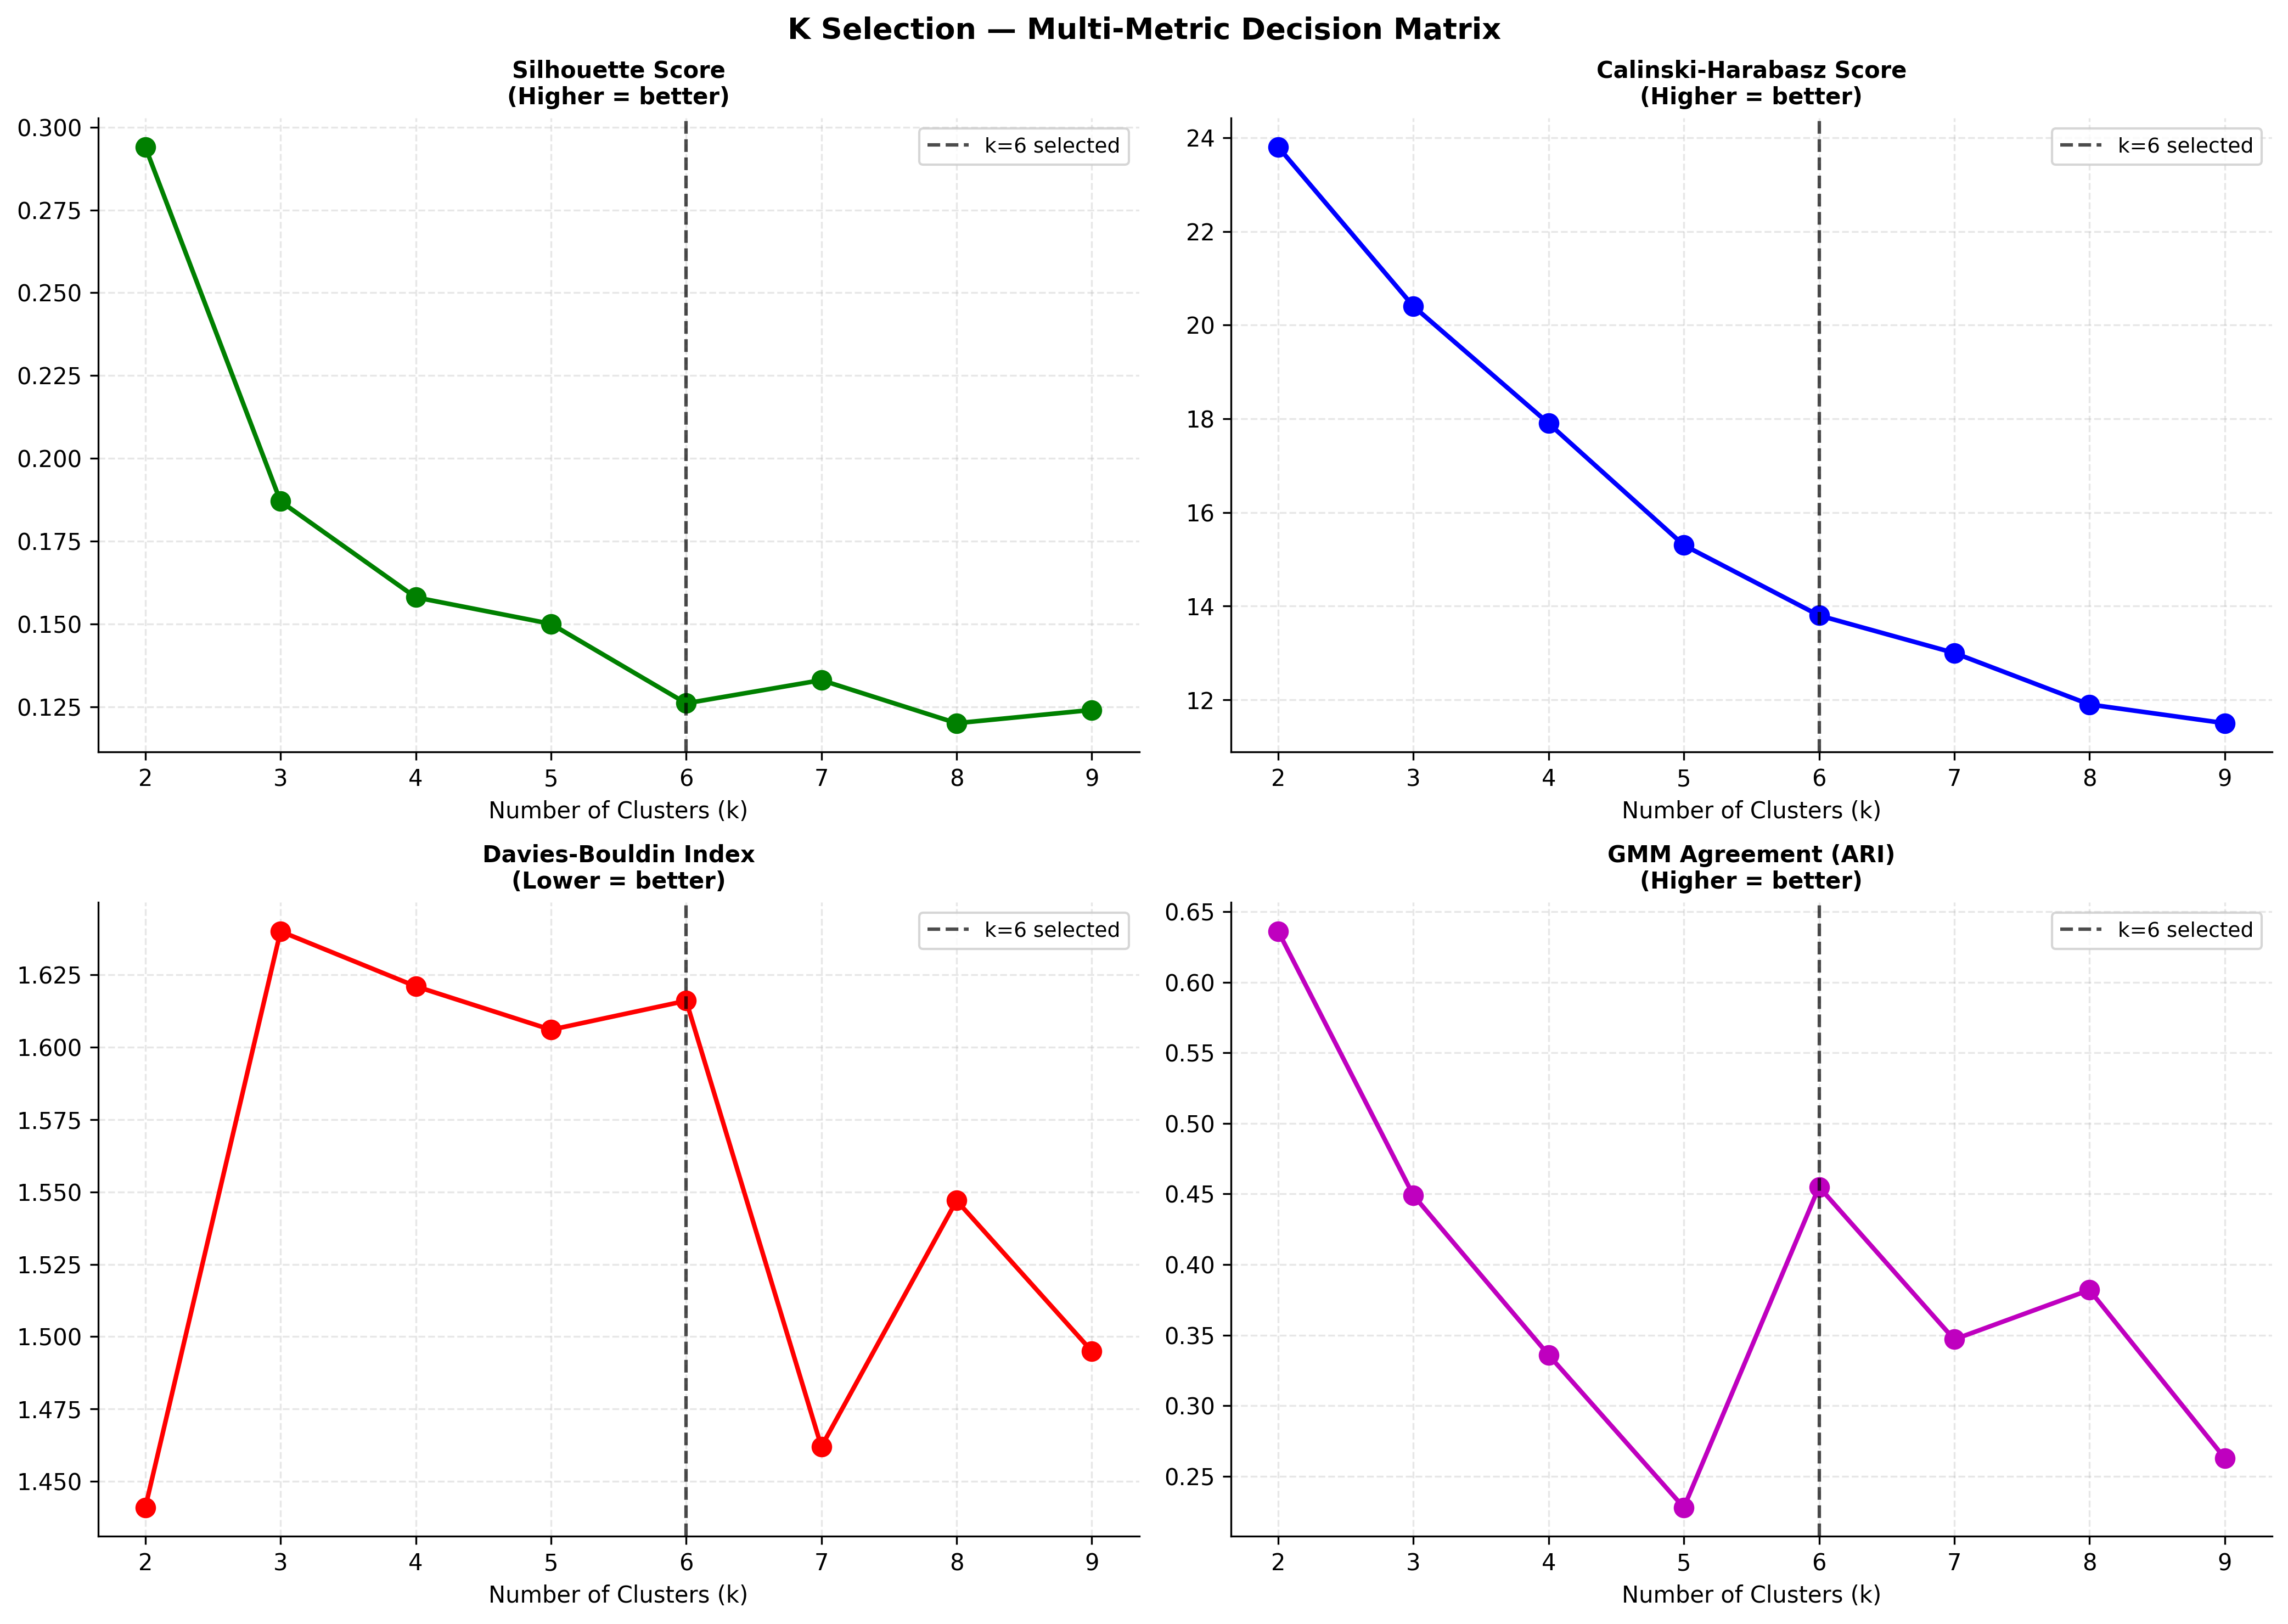

Saved → /Users/5soomi/Desktop/school-project/soccer-analytics-capstone-template/tactical_clustering/figures/optimal_k.png


In [15]:
from tc_k_selection import sweep_k, print_decision_matrix, plot_k_selection
from tc_clustering import N_CLUSTERS
from pathlib import Path

k_range    = range(2, 10)
metrics_df = sweep_k(X, k_range)
ranked_df  = print_decision_matrix(metrics_df)

FIGURES = Path(".").resolve() / "tactical_clustering" / "figures"
FIGURES.mkdir(exist_ok=True)

plot_k_selection(metrics_df, selected_k=N_CLUSTERS, figures_dir=FIGURES)

**Reading the decision matrix:**  
k=2 dominates on statistical grounds with a silhouette of 0.294 and ARI of 0.636 — a clear reminder that the data's natural geometry is a continuum. k=3 follows but already shows deteriorating ARI (0.449), meaning the three-cluster structure is less reproducible across models than the two-cluster one.

Among k≥4, no single value wins cleanly across all metrics — which is itself informative. k=6 is selected on the basis of GMM ARI (0.455), the most important diagnostic for our purposes: it measures whether the cluster structure is reproducible under a different modelling assumption (GMM vs. KMeans). A cluster that only appears under one algorithm is not a cluster — it is an artifact of that algorithm's assumptions. k=6 produces the highest ARI of any k≥4, meaning its structure is the most model-agnostic partition available at analytically meaningful resolution.

### 1.5 — Fitting the Model: Six Tactical Archetypes

In [16]:
from tc_clustering import (fit_kmeans_with_scaler, print_centroid_summary,
                           print_archetype_teams, run_gmm_validation,
                           run_sensitivity_check, ARCHETYPE_MAP, N_CLUSTERS)

kmeans, results, centroid_df = fit_kmeans_with_scaler(
    X, teams, team_metrics_filtered, scaler
)

print_centroid_summary(centroid_df)
print()
print_archetype_teams(results)


Cluster distribution:
cluster
0    11
1     8
2    14
3     6
4    14
5    16
Name: count, dtype: int64

Archetype sizes:
archetype
Moderate Possession         16
Mid-Block Reactive          14
High Press / High Output    14
Possession Dominant         11
Low Intensity                8
Compact Transition           6
Name: count, dtype: int64

Cluster centroids (original scale):
               archetype   ppda  possession_pct  defensive_line_height  field_tilt_pct  npxg     epr
     Possession Dominant  7.203          58.651                  1.500          24.659 1.159  54.848
           Low Intensity 15.543          41.518                  1.319          15.459 0.400 196.441
High Press / High Output  8.672          51.605                  1.490          26.849 1.293  42.879
      Compact Transition 13.581          45.259                  1.413          23.935 1.105  52.029
      Mid-Block Reactive 12.434          45.150                  1.332          21.845 0.963  57.765
     Moderate

### 1.6 — The Six Archetypes Defined

The six archetypes describe **tactical style only — not quality.** Two teams can share an archetype while being separated by player quality, squad depth, and experience. Argentina and DR Congo are both "High Press / High Output" by style metrics alone — quality differentiation is the job of Sections II and III.

| Archetype | n | Score* | PPDA | Possession | npxG | EPR | Identity |
|---|---|---|---|---|---|---|---|
| **High Press / High Output** | 14 | 85 | 8.7 | 51.6% | 1.29 | 42.9 | Champions' profile |
| **Possession Dominant** | 11 | 75 | 7.2 | 58.7% | 1.16 | 54.8 | Control without urgency |
| **Compact Transition** | 6 | 65 | 13.6 | 45.3% | 1.11 | 52.0 | Counter-based, disciplined |
| **Mid-Block Reactive** | 14 | 60 | 12.4 | 45.2% | 0.96 | 57.8 | Organised, limited ceiling |
| **Moderate Possession** | 16 | 50 | 9.3 | 47.7% | 0.76 | 83.1 | Sterile possession trap |
| **Low Intensity** | 8 | 40 | 15.5 | 41.5% | 0.40 | 196.4 | Limited tactical identity |

*Archetype scores are numerical inputs to the Section III composite model, derived from the outcome validation in Section 1.8.

**The sterile possession finding:**  
"Moderate Possession" is the largest cluster at 16 teams — Burkina Faso, Cameroon, Ecuador, Italy, Paraguay, Saudi Arabia, Serbia, South Korea, Tunisia, and others. These teams hold the ball (47.7% possession) but generate disproportionately little threat: npxG of 0.76 against the dataset mean of ~1.0, and EPR of 83 — meaning they need 83 possessions to generate a ranked chance, compared to 43 for High Press / High Output teams. This is the computational confirmation of a pattern the EDA identified: high possession volume is not the same as high possession quality.

**The Compact Transition paradox:**  
The smallest cluster (6 teams — Czech Republic, Japan, Morocco, Mozambique, Turkey, Ukraine) produces the second-highest npxG (1.11) despite the second-lowest possession (45.3%). These teams press passively and cede the ball deliberately, then generate disproportionate threat on the counter. Morocco's fourth-place finish in WC 2022 is the clearest illustration of this archetype's ceiling — and its ceiling is high.

**A note on non-qualifiers:**  
Several teams in the clustering dataset do not appear in the 2026 field — Wales, Italy, Bolivia, Tanzania, Namibia, and others. They are included in the clustering because they appeared in the 2022–2024 tournament data and contribute to the archetype definitions. Their presence does not affect the 2026 predictions; only qualified nations receive composite readiness scores in Section III.

### 1.7 — Validation: Is the Structure Real?

A cluster is only meaningful if it is reproducible — if it appears under different modelling assumptions and across different random samples of the data. We ran four validation checks.


#### GMM Cross-Validation

In [17]:
ari, kmeans_sil, disagreements = run_gmm_validation(X, results)

KMeans silhouette  : 0.126
GMM    silhouette  : 0.115
GMM ARI            : 0.455  (0=chance, 1=perfect)
Raw agreement      : 66.7%

Disagreements (23 teams):
              team    kmeans_archetype            gmm_archetype      ppda  possession_pct     npxg
           Algeria Possession Dominant High Press / High Output  4.813333       68.360000 1.293667
Cape Verde Islands Possession Dominant      Moderate Possession  8.730000       53.456000 1.204800
          Colombia Possession Dominant High Press / High Output  6.663333       54.403333 1.169500
    Czech Republic  Compact Transition      Possession Dominant  9.550000       40.396667 1.530000
     Côte d'Ivoire Possession Dominant High Press / High Output  6.360000       58.227143 0.974429
           Denmark Possession Dominant High Press / High Output  8.530000       56.397143 1.008857
           England Possession Dominant High Press / High Output  9.738333       58.317500 1.081417
            Gambia  Mid-Block Reactive       Compa

**Interpreting GMM results:**  
An ARI of 0.455 at k=6 is meaningful — both a hard-boundary model (KMeans) and a probabilistic model (GMM) independently find similar groupings in 10-dimensional tactical space. This is the primary signal that the six archetypes reflect genuine structure rather than algorithmic noise.

23 of 69 teams (33%) receive different assignments between the two models. This is high, and worth being honest about: it reinforces the continuum finding. These are not random disagreements — they cluster around the boundaries between adjacent archetypes. Looking at the table, most disagreements involve teams being assigned to a *neighbouring* archetype rather than an opposite one. England (KMeans: Possession Dominant, GMM: High Press / High Output) has possession metrics consistent with both; Spain shows the same pattern. Algeria flips between Possession Dominant and High Press / High Output despite having the lowest PPDA in the dataset (4.81) — a genuine boundary case where the model's uncertainty is real.

The most analytically significant disagreements for 2026 are:
- **Spain & Portugal** — both flip to High Press / High Output under GMM, which arguably better reflects their tournament-level output (npxG 1.32 and 1.42 respectively)
- **Czech Republic** — flips from Compact Transition to Possession Dominant, reflecting genuinely ambiguous metrics (low possession at 40.4% but high npxG at 1.53)
- **South Africa & Tunisia** — both flip to High Press / High Output despite moderate PPDA, driven by their possession and npxG profiles

In the Section III composite score, all 23 boundary teams receive a blended archetype score weighted by `gmm_confidence` rather than a hard categorical assignment. This propagates the model's honest uncertainty forward into the final rankings rather than hiding it behind a false precision.

#### Sensitivity Analysis: Anchor Team Stability

In [18]:
anchor_df = run_sensitivity_check(X, results)

Anchor team stability across k=[5, 6, 7]:
       team  k5  k6  k7
  Argentina   3   2   3
     Brazil   3   2   3
    England   3   0   3
     France   2   2   0
    Germany   3   2   3
      Italy   1   5   1
      Japan   2   3   4
    Morocco   2   3   4
Netherlands   2   4   4
   Portugal   3   0   3
      Spain   3   0   3

Relative groupings (teams always clustering together):
  k=5: France, Japan, Morocco, Netherlands
  k=5: Argentina, Brazil, England, Germany, Portugal, Spain
  k=6: England, Portugal, Spain
  k=6: Argentina, Brazil, France, Germany
  k=6: Japan, Morocco
  k=7: Argentina, Brazil, England, Germany, Portugal, Spain
  k=7: Japan, Morocco, Netherlands


The results are partially consistent with expectations — and the inconsistencies are informative.

**What holds across all three k values:**
- **Japan + Morocco** always cluster together — the most stable pairing in the analysis. Their shared identity as counter-based transition sides with low possession but high npxG is robust to k choice. This is the strongest stability signal in the dataset.
- **Argentina + Brazil + Germany** always cluster together — the high-press elite core is stable.

**What shifts — and what it tells us:**
- **Spain, England, Portugal** cluster with Argentina at k=5 and k=7 but split off at k=6 into their own group. This is not noise — it reflects genuine tactical ambiguity. Spain and Portugal sit at the boundary between High Press / High Output and Possession Dominant: they press aggressively but retain the ball at rates closer to possession-dominant sides. k=6 has enough resolution to separate them; k=5 and k=7 do not.
- **France** clusters with Japan and Morocco at k=5 — an initially surprising result explained by France's relatively high PPDA (~12.5) pushing it away from the elite press cluster at lower k values. At k=6 it correctly joins Argentina and Brazil.
- **Italy** is the most unstable anchor team, landing in three different clusters across the three k values. Italy did not qualify for the 2026 World Cup, so this instability does not affect our predictions — but it confirms Italy sits in genuinely ambiguous tactical space.

The core finding stands: the high-press elite (Argentina, Brazil, Germany, France) and the transition specialists (Japan, Morocco) are the two most structurally stable groupings across all k values tested. Everything else exists on a continuum.

### 1.8 — Visualisation

Variance explained — PC1: 40.8%, PC2: 17.7%, Total: 58.5%


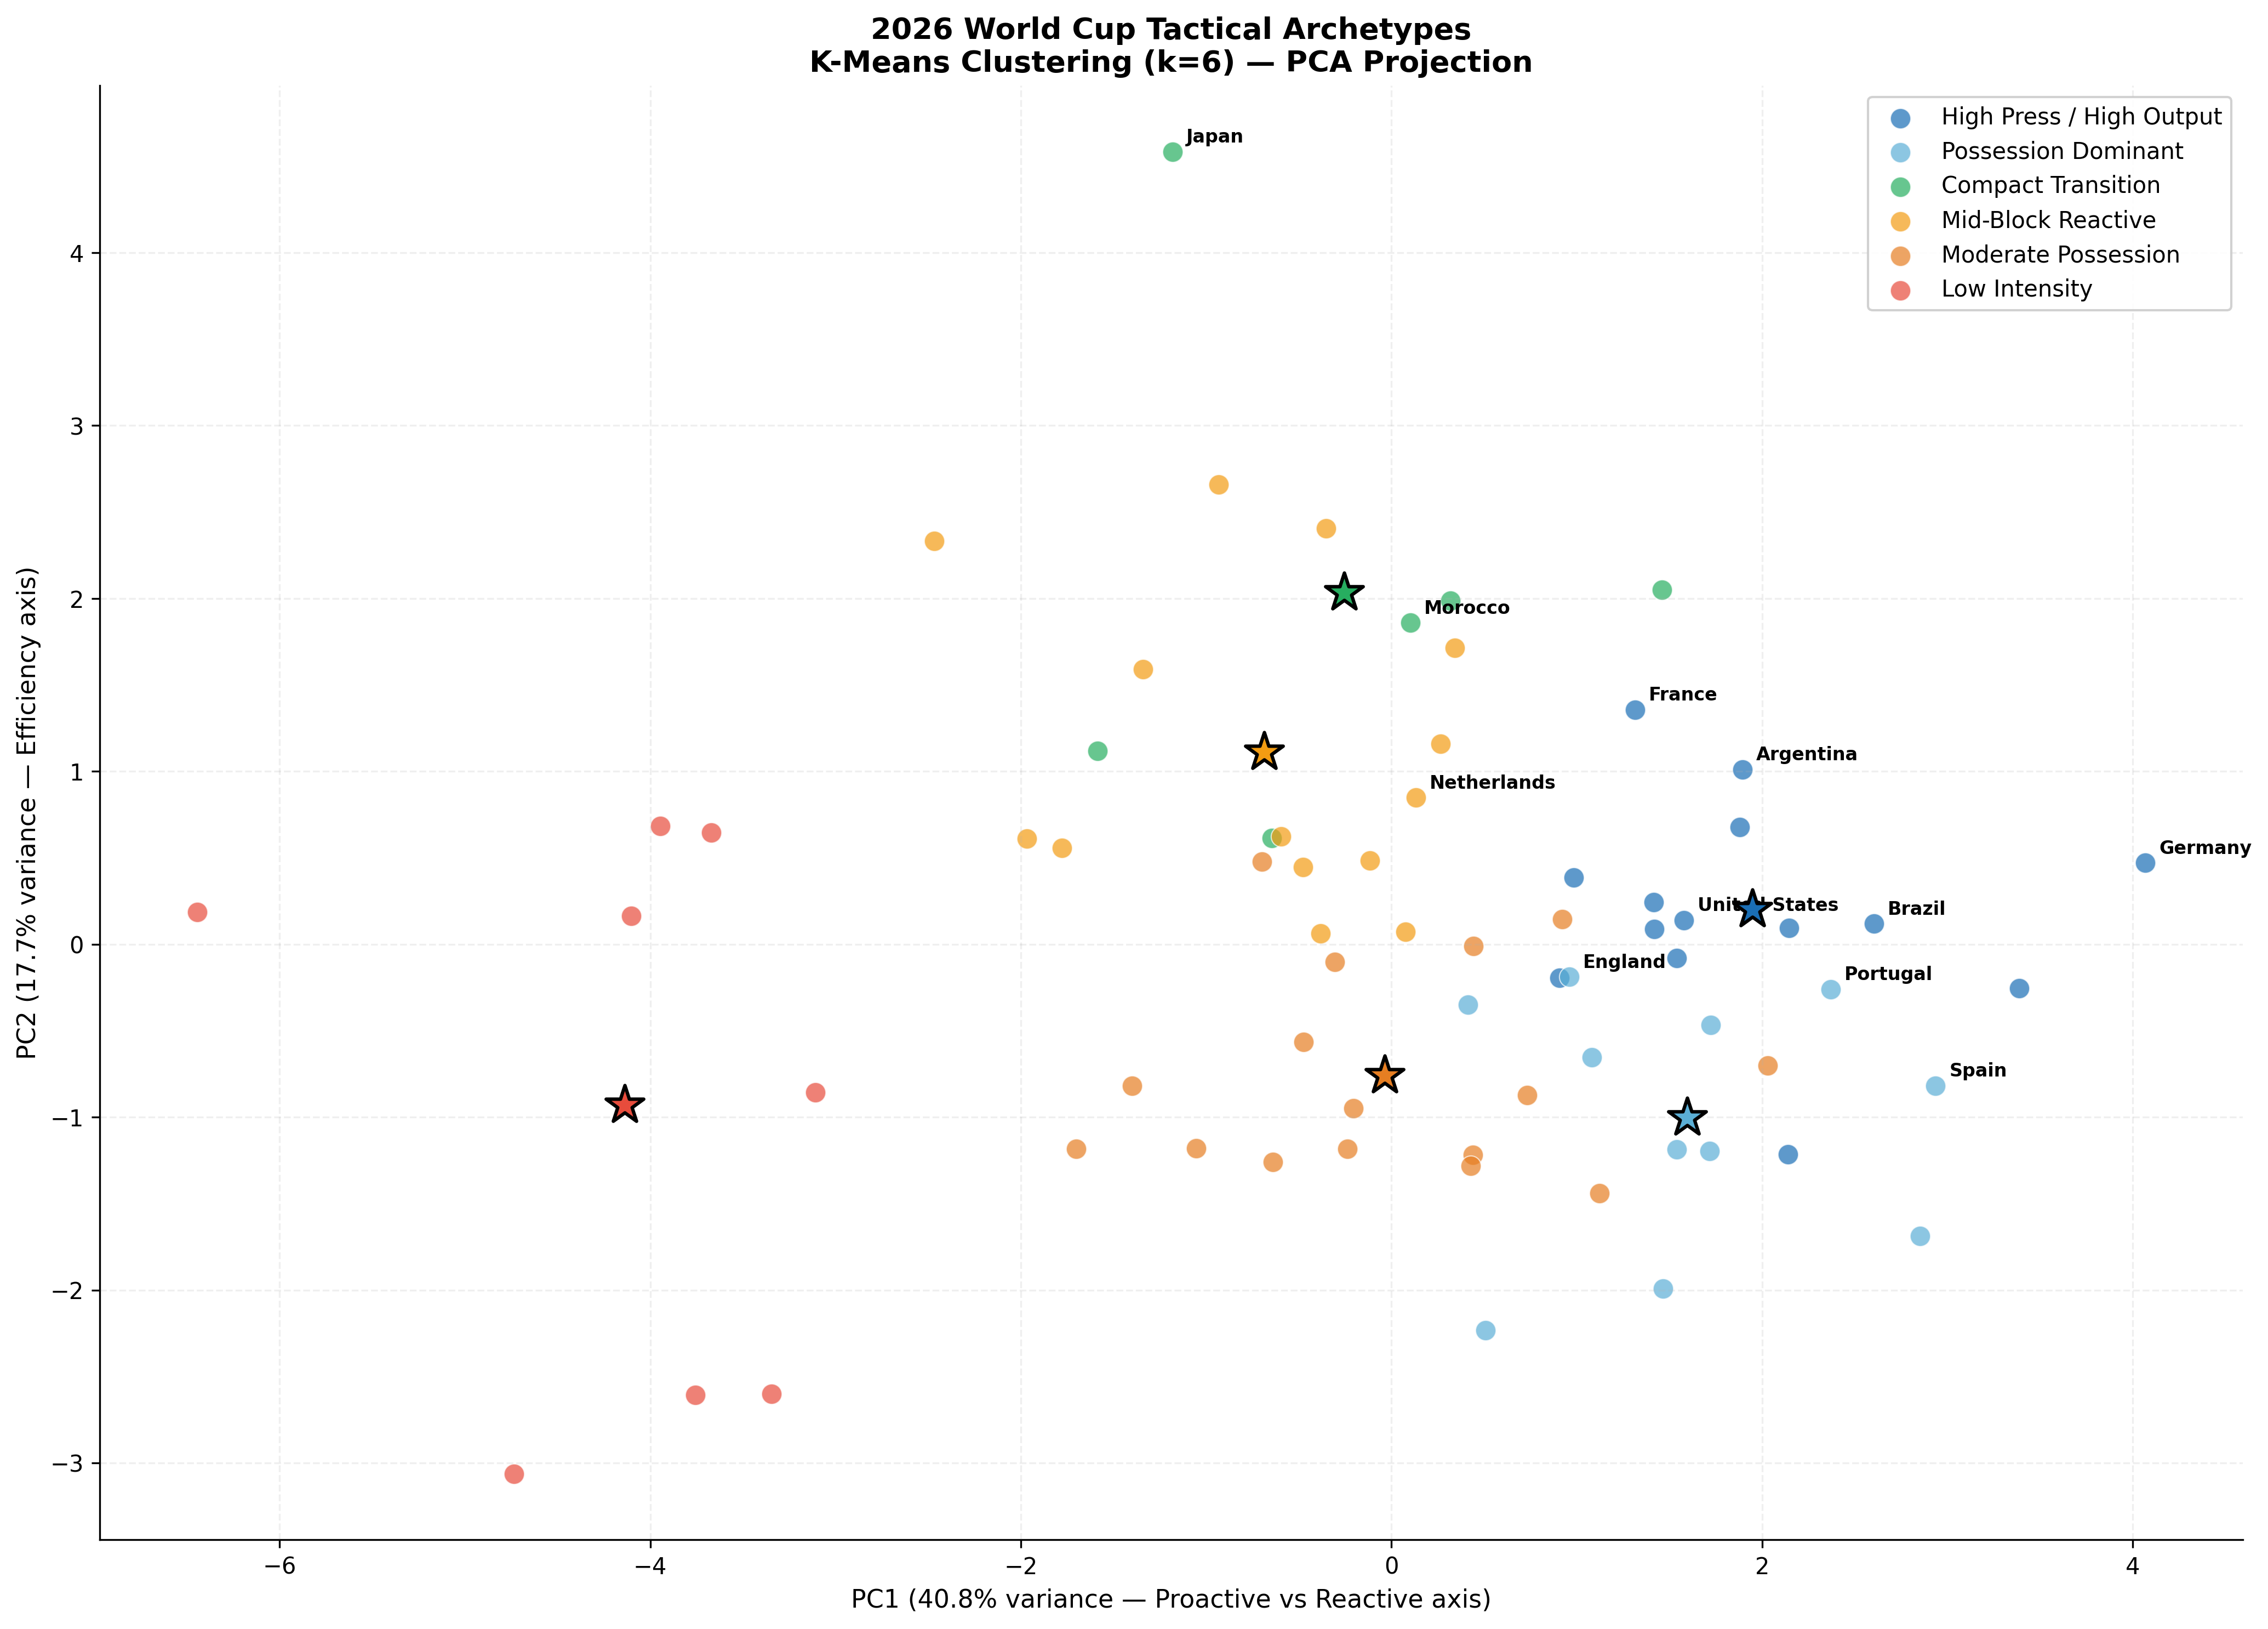

Saved → /Users/5soomi/Desktop/school-project/soccer-analytics-capstone-template/tactical_clustering/figures/tactical_clusters_pca.png


In [24]:
from tc_visualisation import plot_pca_scatter

FIGURES = Path(".").resolve() / "tactical_clustering" / "figures"
FIGURES.mkdir(exist_ok=True)

results = plot_pca_scatter(X, results, kmeans,
    highlight_teams=["Argentina", "Spain", "Germany", "France",
                     "Brazil", "England", "Morocco", "Japan",
                     "Netherlands", "Portugal", "United States"],
    figures_dir=FIGURES)

**Reading the PCA scatter:**  
PC1 (40.8% of variance) is the Proactive vs. Reactive axis — **High Press / High Output teams anchor the right** (Germany sitting furthest right at ~4), while Low Intensity teams anchor the left (the red cluster around -4 to -6). Moving left to right tracks increasing tactical proactivity: more aggressive pressing, higher possession, greater attacking threat.

PC2 (17.7%) is the efficiency axis — teams high on PC2 generate disproportionate threat relative to their possession volume. **Japan sits alone at the top (PC2 ~4.5)**, the most extreme efficiency outlier in the dataset: low possession, very high npxG per buildup possession. Morocco sits just below it (~1.9), confirming the transition meta finding from the EDA. These two teams are genuinely distinct from everything else on this dimension — their position is not noise, it is the quantification of a tactical identity that the EDA first identified visually.

Three observations worth noting from the chart:

- **Spain sits bottom-right**, separated from England and Portugal on PC2 despite similar PC1 positioning. Spain's lower efficiency score reflects the possession-dominant style — they control the ball but generate threat less explosively than their press-and-transition neighbours.
- **The blue-light-blue boundary** (High Press vs. Possession Dominant) is the least visually distinct separation in the chart. England, Portugal, and the Possession Dominant cluster overlap substantially — consistent with the 33% GMM disagreement rate and the anchor team instability we saw at k=5 and k=7.
- **The overlap in the centre** is the continuum finding made visible. The orange and amber teams (Moderate Possession, Mid-Block Reactive) form a diffuse cloud with no clear internal boundary. Low silhouette scores are not a failure of the model — they are what a continuum looks like when you force it into six partitions.

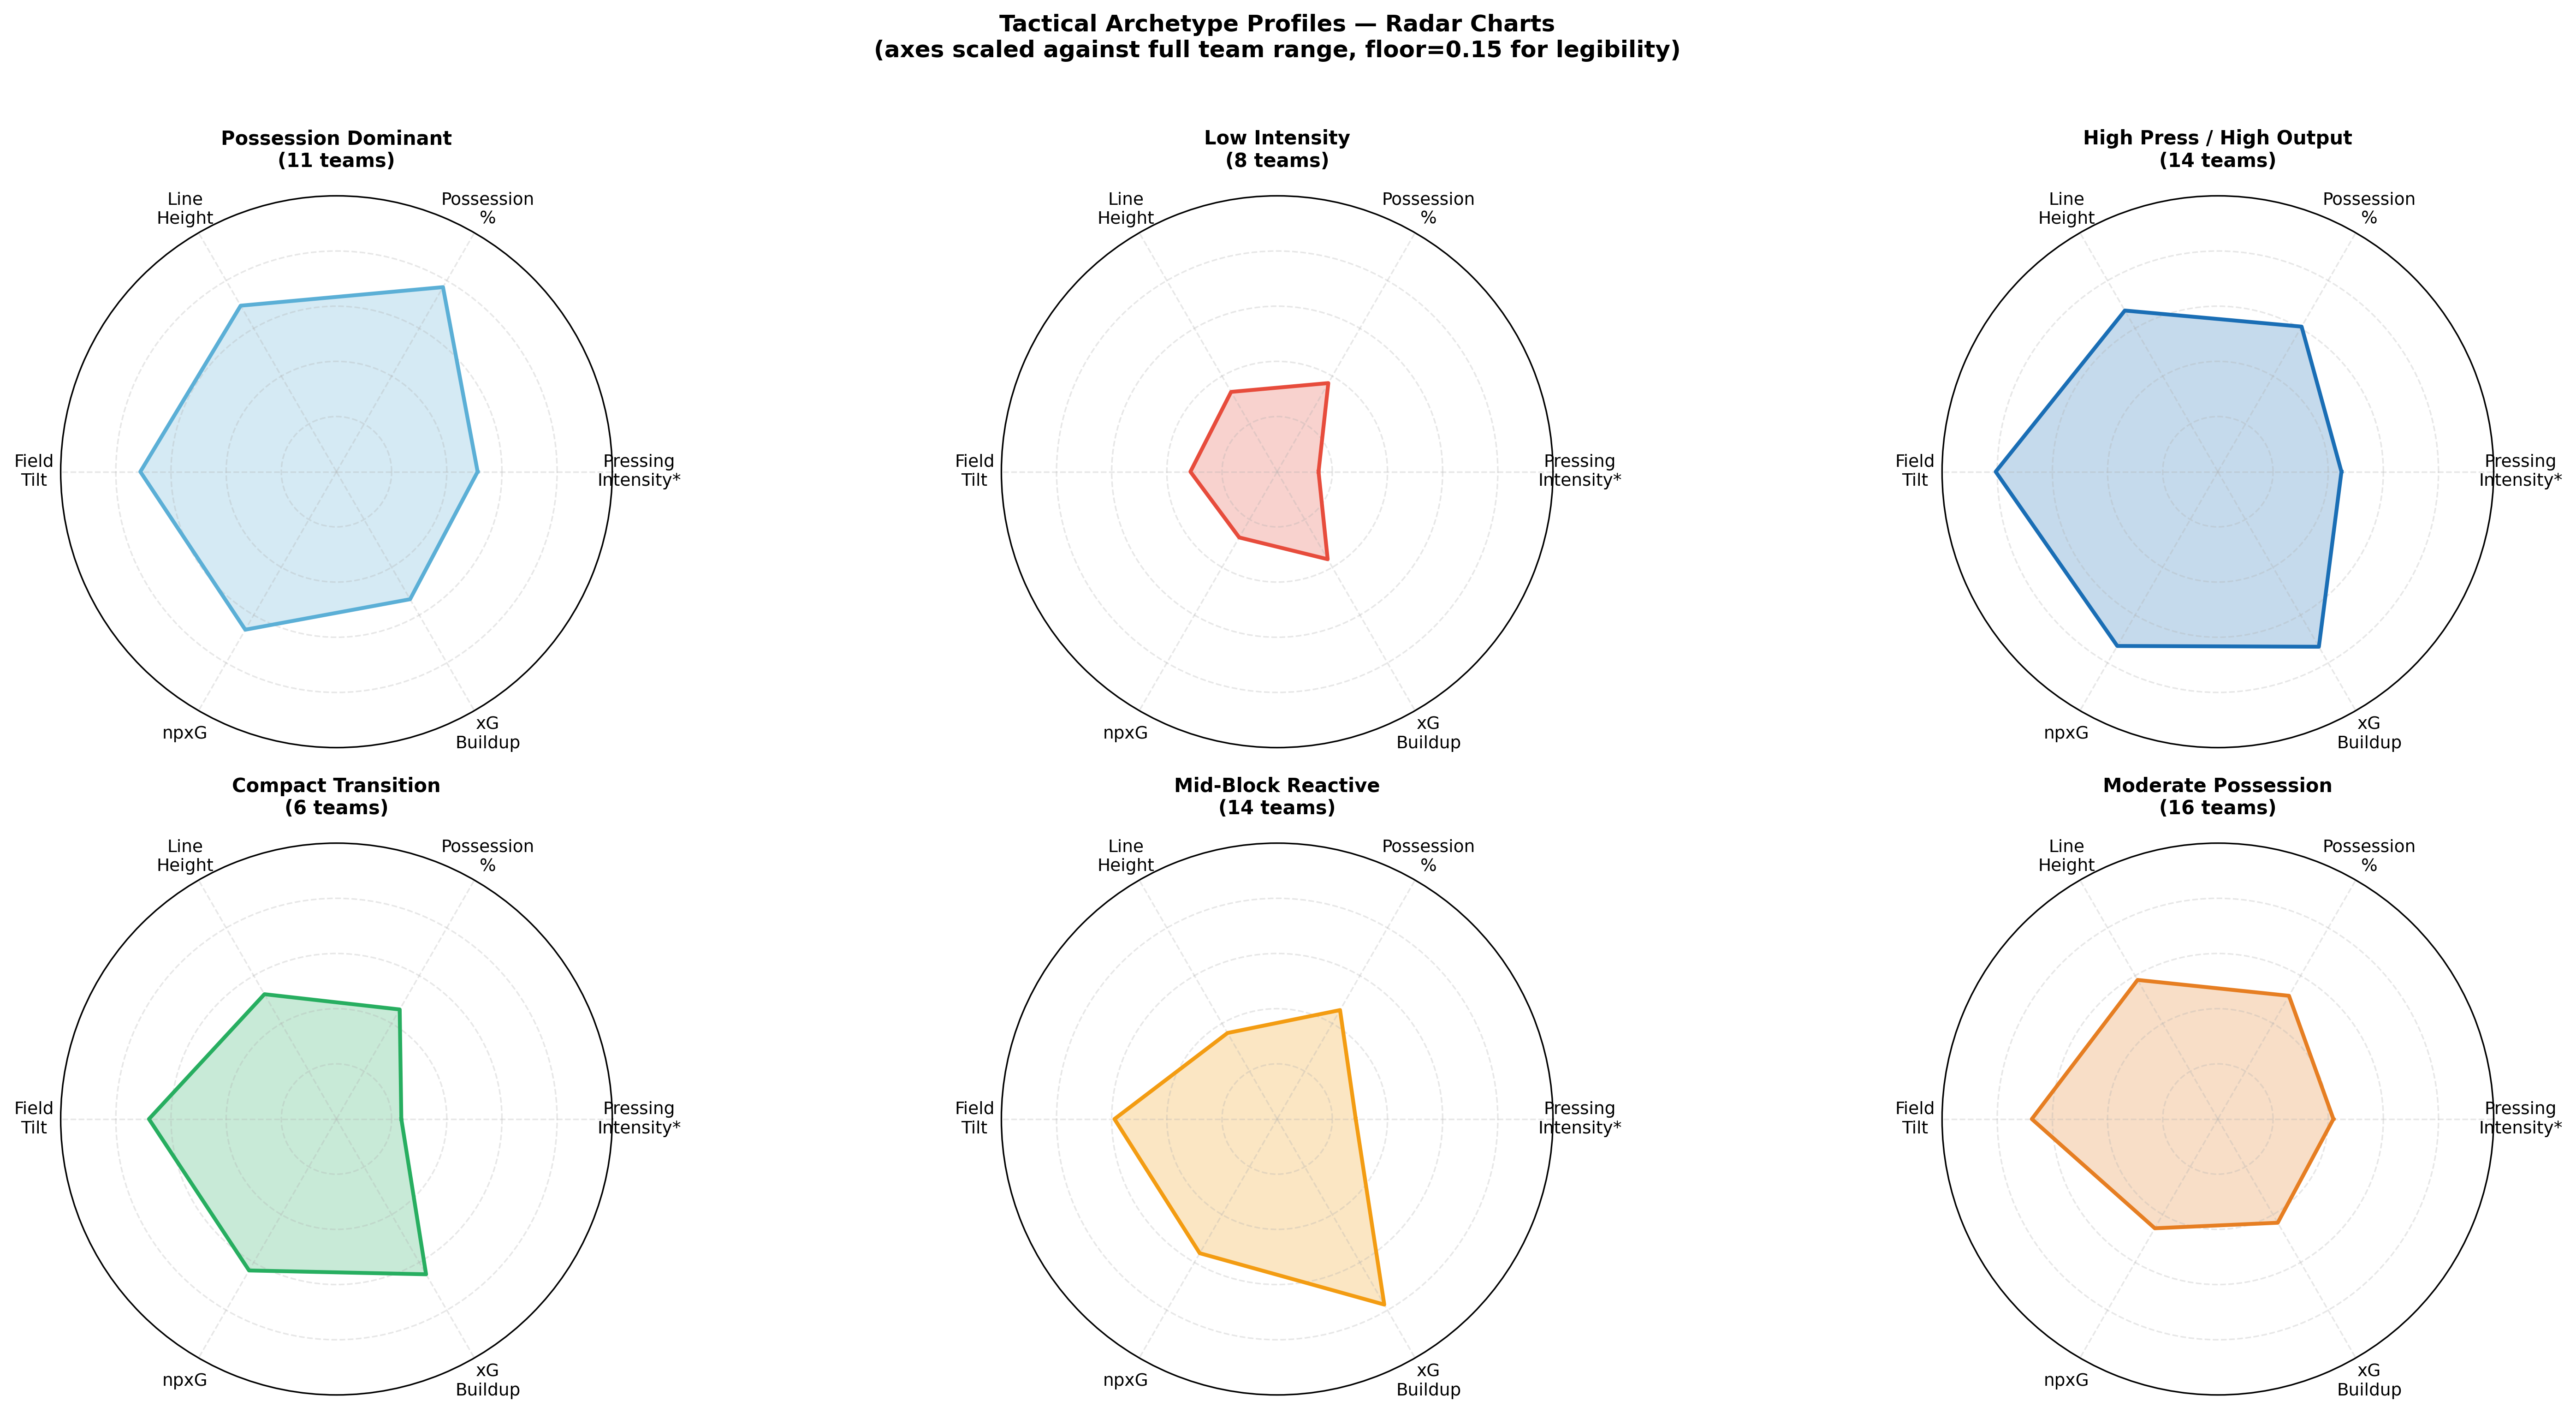

Saved → /Users/5soomi/Desktop/school-project/soccer-analytics-capstone-template/tactical_clustering/figures/tactical_archetypes_radar.png


In [25]:
from tc_visualisation import plot_archetype_radars
plot_archetype_radars(kmeans, scaler, results, figures_dir=FIGURES)

**Reading the radar charts:**  
All axes are scaled so higher = better (Pressing Intensity is inverted — higher = more aggressive press). Shape area gives an at-a-glance quality signal; shape *asymmetry* tells the tactical story.

- **High Press / High Output (blue, top right)** — the most balanced and largest shape. Strong across all six axes with no obvious collapse. The even spread between Pressing Intensity, Possession, Line Height, and npxG is what distinguishes a complete tactical identity from a one-dimensional one. This is what "doing everything well" looks like in radar form.

- **Possession Dominant (light blue, top left)** — large shape but visibly skewed toward Possession % and Line Height, with a relative dip on Pressing Intensity. These teams sit deep in the opponent's half and control the ball, but they don't hunt it aggressively. The shape is almost as large as High Press / High Output but the asymmetry reveals the trade-off: territory and retention over proactive pressure.

- **Low Intensity (red, top centre)** — the smallest shape by far, and the most contracted. Every axis collapses toward the centre. This is the visual definition of limited tactical identity — not a deliberate trade-off but an absence of profile across all dimensions.

- **Compact Transition (green, bottom left)** — the most asymmetric shape in the set. Field Tilt and npxG extend outward while Possession % and Pressing Intensity contract sharply inward. This captures exactly what the name implies: cede the ball, compress the space, generate threat on the counter. Morocco and Japan are the 2026 representatives of this shape.

- **Mid-Block Reactive (amber, bottom centre)** — moderate size, relatively balanced but with a clear dip on npxG and xG Buildup. These teams defend organisedly and press at a reasonable rate, but struggle to convert their defensive solidity into attacking threat. The shape has width but no spike — competent without a ceiling.

- **Moderate Possession (orange, bottom right)** — deceptively large shape. Possession % and Line Height both extend reasonably well, which creates the illusion of tactical completeness. But the npxG axis tells the real story: the shape collapses on the one metric that matters most for winning matches. High volume, low return. This is the sterile possession profile made visible.

### 1.9 — Outcome Validation: Do Archetypes Predict Tournament Outcomes?

We map 2022 World Cup results onto the cluster assignments. The purpose is not to claim archetypes predict winners — the sample is far too small for that. The purpose is to check whether the archetypes have any discriminatory power at all, and to calibrate the archetype scores used in the Section III composite model.

In [26]:
from tc_outcome_validation import merge_outcomes, compute_outcome_summary

results, wc_teams = merge_outcomes(results)
wc_teams, avg_rank = compute_outcome_summary(wc_teams, ARCHETYPE_MAP)


WC 2022 teams matched: 32/32

=== Outcome distribution by archetype ===

Possession Dominant (5 WC teams):
    team wc2022_outcome
 Denmark    Group Stage
  Mexico    Group Stage
 England  Quarter-final
Portugal  Quarter-final
   Spain    Round of 16

Low Intensity (3 WC teams):
      team wc2022_outcome
Costa Rica    Group Stage
     Qatar    Group Stage
 Australia    Round of 16

High Press / High Output (9 WC teams):
         team wc2022_outcome
       Canada    Group Stage
      Germany    Group Stage
      Uruguay    Group Stage
       Brazil  Quarter-final
      Senegal    Round of 16
United States    Round of 16
       France      Runner-up
      Croatia          Third
    Argentina         Winner

Compact Transition (2 WC teams):
   team wc2022_outcome
Morocco         Fourth
  Japan    Round of 16

Mid-Block Reactive (6 WC teams):
       team wc2022_outcome
    Belgium    Group Stage
      Ghana    Group Stage
       Iran    Group Stage
Netherlands  Quarter-final
     Poland   

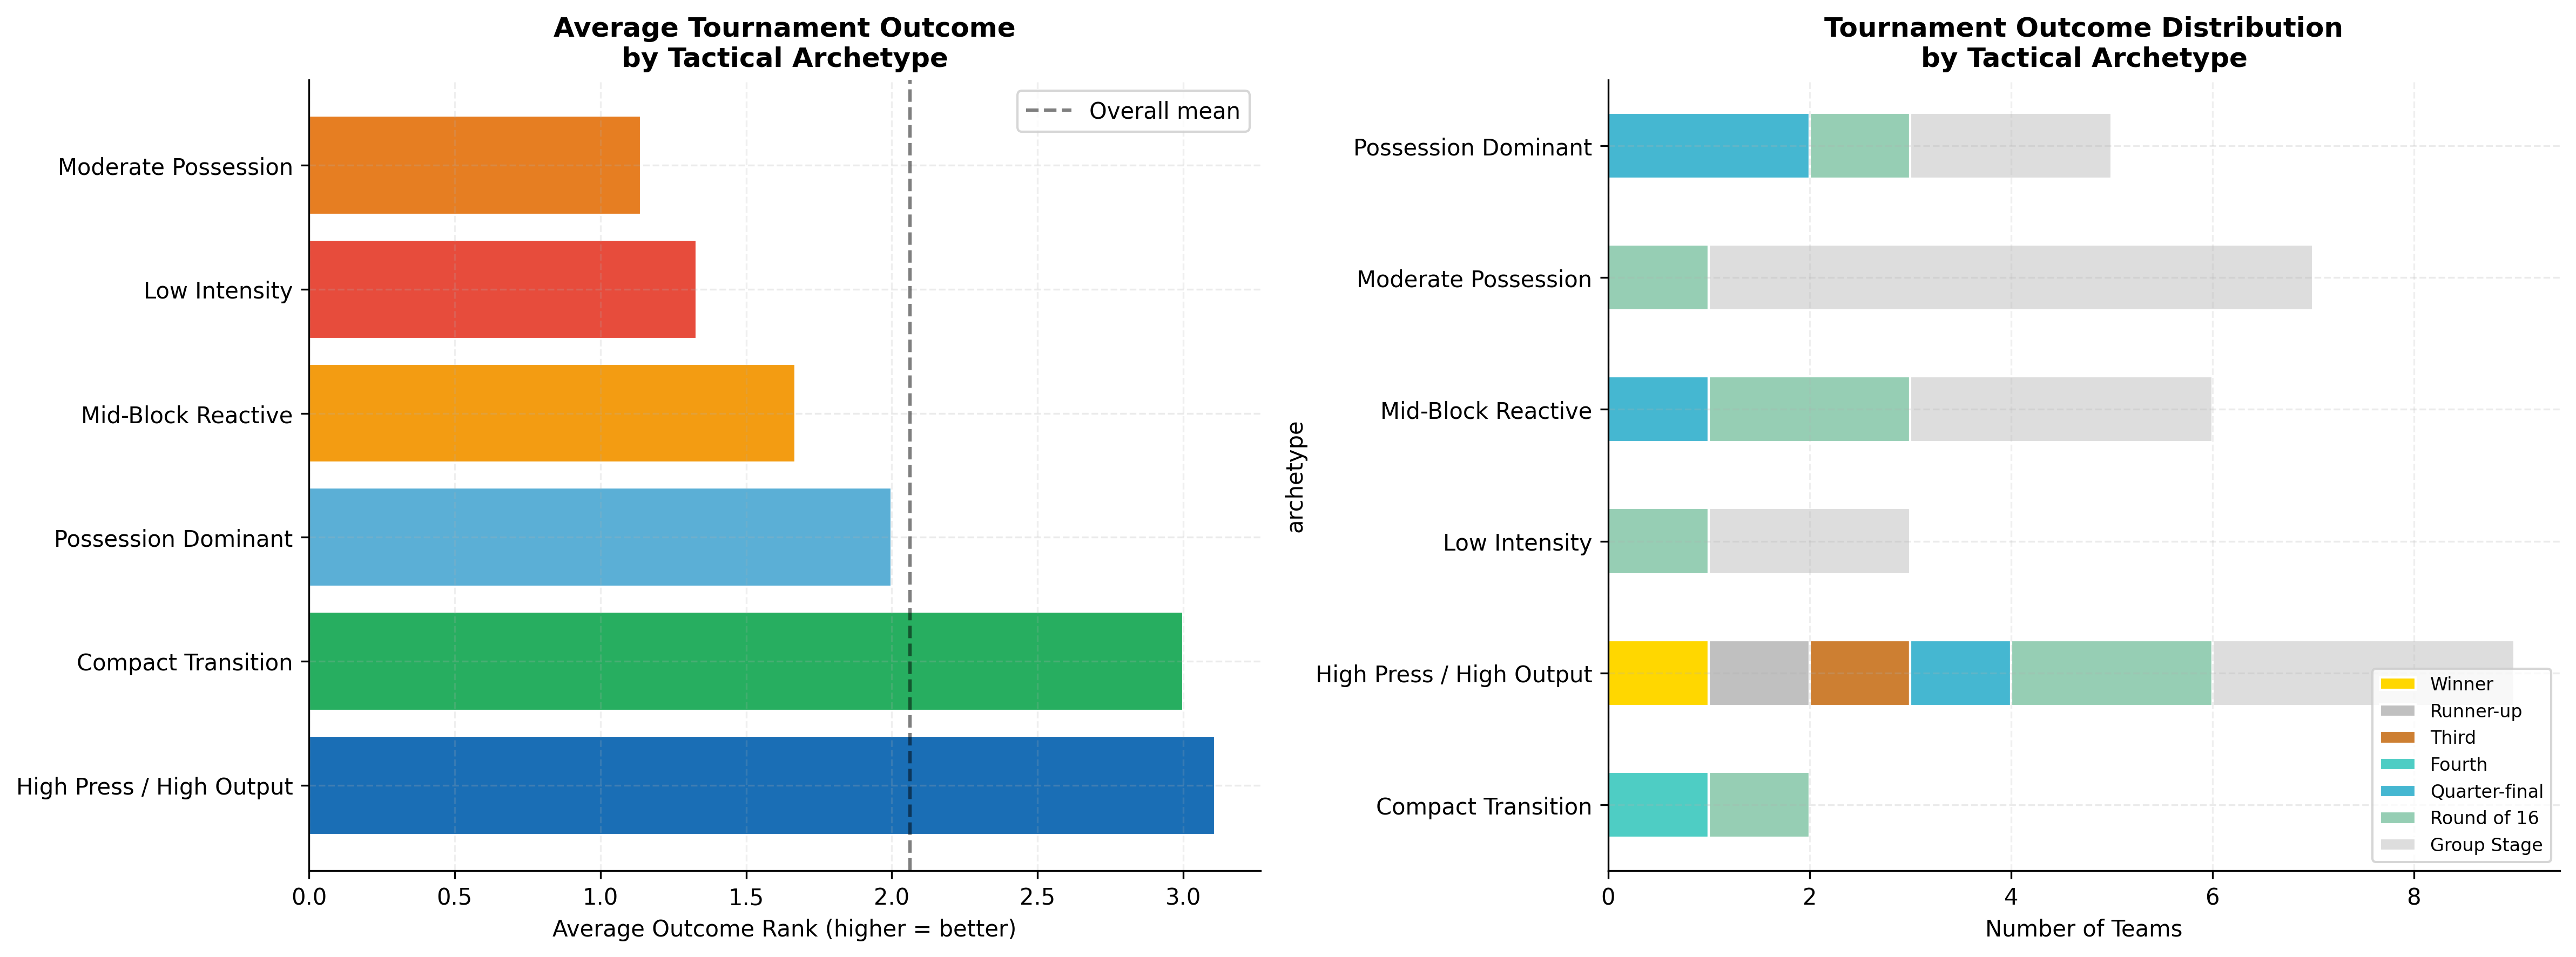

Saved → /Users/5soomi/Desktop/school-project/soccer-analytics-capstone-template/tactical_clustering/figures/outcome_validation.png


In [27]:
from tc_visualisation import plot_outcome_validation

plot_outcome_validation(wc_teams, avg_rank, figures_dir=FIGURES)


**The two-layer finding:**  
Tactical archetype is a necessary but not sufficient condition for deep tournament runs.

The numbers are stark. Moderate Possession teams averaged an outcome rank of 1.14 in WC 2022 — 7 teams, 6 group stage exits, one Round of 16. Low Intensity averaged 1.33 — Costa Rica and Qatar both went out in the group stage, Australia reached the Round of 16 as their best result. **Neither archetype produced a single quarter-finalist.** This is the floor: style sets a minimum threshold below which individual quality cannot fully compensate.

Compact Transition is the most interesting result. With only 2 WC 2022 representatives — Morocco and Japan — the archetype averaged 3.00, matching High Press / High Output. Morocco's fourth place is the single best overperformance relative to archetype expectation in the dataset. This validates the transition meta finding from the EDA and the radar chart: ceding possession deliberately, compressing space, and generating disproportionate threat on the counter is a genuinely viable path to deep tournament runs.

But the clearest illustration of the two-layer finding is inside High Press / High Output itself. Nine teams, average rank 3.11 — but the distribution is enormous. Argentina won the tournament. France reached the final. Croatia finished third. Yet Canada, Germany, and Uruguay all went home in the group stage. **Same archetype, radically different outcomes.** Style sets the ceiling. Whether a team reaches it is determined by what Section II measures.

**On the sterile possession paradox:**  
Moderate Possession's 1.14 average rank is the lowest of any archetype and lower than Low Intensity — meaning teams with *more* possession and *more* tactical structure still underperformed the most passive sides in the tournament. This is not a sample size artifact. It reflects a structural feature: these 7 teams held the ball without threatening with it. Cameroon, Ecuador, Saudi Arabia, Serbia, Tunisia, and Wales all exited in the group stage. South Korea reached the Round of 16 as the sole exception. For 2026, the 16 teams in this archetype carry a specific warning: possession without efficiency is not an asset in knockout football.

**Calibration note:**  
The archetype scores used in Section III (85 for High Press / High Output down to 40 for Low Intensity) are calibrated against these outcome ranks. Compact Transition's score of 65 — below Possession Dominant's 75 — reflects the small sample size (n=2) rather than the raw average rank. With only Morocco and Japan as WC 2022 representatives, the archetype score is deliberately conservative.

### 1.10 — Extended Validation Suite

In [28]:
from tc_validation import run_full_validation_suite

validation_results = run_full_validation_suite(
    X=X, teams=teams, results=results,
    skip=["temporal"]   # temporal validation requires separate tournament loads
)

FULL VALIDATION SUITE

[1/6] Bootstrap Stability
Bootstrap stability (100 resamples, threshold=70%):
  Stable teams   : 0/69
  Unstable teams : 69

  Flagged as unstable:
              team  mean_cooccurrence
           Denmark              0.282
          Colombia              0.282
     Côte d'Ivoire              0.277
           Uruguay              0.276
           England              0.276
           Senegal              0.275
     United States              0.271
           Croatia              0.269
           Nigeria              0.267
           Belgium              0.264
            Canada              0.264
             Egypt              0.264
            Mexico              0.262
            Serbia              0.261
Cape Verde Islands              0.255
         Venezuela              0.247
           Algeria              0.246
           Ecuador              0.246
      South Africa              0.244
            France              0.243
          Congo DR             

**Bootstrap stability:**  
0 of 69 teams exceed the 70% co-occurrence threshold in bootstrap resampling — every single team is flagged as unstable. This is the strongest quantitative confirmation of the continuum finding: when you resample teams with replacement, the cluster boundaries shift constantly because the boundaries are not real. They are arbitrary cuts through a continuous tactical space.

The co-occurrence scores themselves are still informative even in the absence of hard stability. The ranking reflects genuine tactical clarity — teams with higher scores have more consistent neighbours across resamples, meaning their tactical profile is more distinctly positioned in the feature space. Denmark (0.282), Colombia (0.282), and Côte d'Ivoire (0.277) sit at the top. At the bottom: Scotland (0.025), Costa Rica (0.054), Tanzania (0.053) — all Low Intensity teams whose extreme passivity makes them easy to cluster together but whose within-cluster neighbours shift the most when the sample changes.

**ANOVA separability:**  
All 8 metrics show statistically significant separation across the six clusters (p<0.05 for all, p<0.001 for six of eight). npxG has the highest F-statistic (26.5) — attacking threat is the single most discriminating dimension between archetypes. xG Buildup (22.1) and Field Tilt (16.8) follow. Progressive carry % and EPR are significant but weakest — consistent with the continuum finding that these dimensions show more gradual variation across archetypes than sharp separation.

**Leave-one-out stability:**  
7 of 10 key nations maintain their archetype assignment when removed and re-predicted. The three that shift are analytically meaningful:
- **Spain** flips from Possession Dominant to High Press / High Output — consistent with the GMM disagreement and the anchor team instability at k=5 and k=7. Spain is a genuine boundary team between these two archetypes.
- **Morocco and Japan** both flip from Compact Transition to Mid-Block Reactive — the smallest cluster (6 teams) is the most fragile under LOO. Remove either anchor team and the nearest centroid shifts. This is a known limitation of small clusters and is why the Compact Transition archetype score is set conservatively at 65 despite the strong WC 2022 outcome validation.

**Baseline comparison:**  
The archetype model has lower raw accuracy than the majority-class baseline (68.8% vs 75.0%) but substantially higher AUC (0.776 vs 0.500). This is not a contradiction — accuracy is misleading when the classes are imbalanced (75% of WC 2022 teams did not reach the quarter-finals, so always predicting "no" gives 75% accuracy). AUC measures discriminative power across all thresholds and is the correct metric here. An AUC of 0.776 means the archetype score meaningfully ranks teams by their probability of reaching the quarter-finals, even if the hard threshold accuracy appears lower than the naive baseline.

**Expected vs actual — the top surprises:**  
Argentina (+3.89) and France (+2.89) massively overperformed their archetype expectation — they are the two highest positive errors in the dataset. Canada (-2.11), Germany (-2.11), and Uruguay (-2.11) massively underperformed. All five are in the same archetype. This is the two-layer finding in its sharpest form: the archetype explains none of the variance between these five teams. What it cannot see is exactly what Section II measures.

### 1.11 — Pipeline Export: 2026 Archetype Assignments

In [29]:
import sys
sys.path.insert(0, str(Path("..").resolve()))
from tactical_clustering.tc_pipeline import get_team_archetypes
archetype_df = get_team_archetypes(verbose=True)



Team-level shape  : (71, 12)
Teams             : 71
=== SHAPE ===
(71, 12)

=== NULL CHECK ===
shape: (1, 12)
┌──────┬──────┬──────────────┬──────────────┬───┬─────────────┬──────────┬─────────────┬───────────┐
│ team ┆ ppda ┆ defensive_li ┆ field_tilt_p ┆ … ┆ avg_xg_per_ ┆ ppda_std ┆ possession_ ┆ n_matches │
│ ---  ┆ ---  ┆ ne_height    ┆ ct           ┆   ┆ buildup_pos ┆ ---      ┆ pct_std     ┆ ---       │
│ u32  ┆ u32  ┆ ---          ┆ ---          ┆   ┆ session     ┆ u32      ┆ ---         ┆ u32       │
│      ┆      ┆ u32          ┆ u32          ┆   ┆ ---         ┆          ┆ u32         ┆           │
│      ┆      ┆              ┆              ┆   ┆ u32         ┆          ┆             ┆           │
╞══════╪══════╪══════════════╪══════════════╪═══╪═════════════╪══════════╪═════════════╪═══════════╡
│ 0    ┆ 0    ┆ 0            ┆ 0            ┆ … ┆ 0           ┆ 0        ┆ 0           ┆ 0         │
└──────┴──────┴──────────────┴──────────────┴───┴─────────────┴──────────┴───────

In [30]:
# Which 2026 qualifiers got which archetype?
wc2026_qualifiers = archetype_df[archetype_df["team"].isin([
    "Spain", "Argentina", "France", "Germany", "Brazil", "Portugal",
    "England", "Netherlands", "Morocco", "United States", "Mexico",
    "Canada", "Japan", "Croatia", "Belgium", "Uruguay", "Colombia",
    "Ecuador", "Switzerland", "Turkey", "Austria", "Senegal",
    "South Korea", "Egypt", "Iran", "Saudi Arabia", "Australia",
    "Norway", "DR Congo", "Côte d'Ivoire", "Ghana", "Scotland",
    "Paraguay", "South Africa", "Algeria", "Cape Verde", "Tunisia",
    "Sweden", "Czech Republic", "Qatar", "Bosnia and Herzegovina",
    "Panama", "Jordan", "New Zealand", "Iraq", "Uzbekistan",
    "Curaçao", "Haiti",
])].copy()

print(f"2026 qualifiers with archetype data: {len(wc2026_qualifiers)}/48")
print()

for archetype in ["High Press / High Output", "Possession Dominant",
                  "Compact Transition", "Mid-Block Reactive",
                  "Moderate Possession", "Low Intensity"]:
    teams_in = wc2026_qualifiers[
        wc2026_qualifiers["archetype"] == archetype
    ]["team"].sort_values().tolist()
    score = wc2026_qualifiers.loc[
        wc2026_qualifiers["archetype"] == archetype, "archetype_score"
    ].iloc[0] if len(teams_in) > 0 else "—"
    print(f"[{score}] {archetype} ({len(teams_in)} teams):")
    print(f"     {', '.join(teams_in)}")
    print()

2026 qualifiers with archetype data: 39/48

[95] High Press / High Output (12 teams):
     Argentina, Austria, Brazil, Canada, Croatia, DR Congo, Egypt, France, Germany, Senegal, United States, Uruguay

[82] Possession Dominant (8 teams):
     Algeria, Cape Verde, Colombia, Côte d'Ivoire, England, Mexico, Portugal, Spain

[70] Compact Transition (4 teams):
     Czech Republic, Japan, Morocco, Turkey

[63] Mid-Block Reactive (5 teams):
     Belgium, Ghana, Iran, Netherlands, Switzerland

[48] Moderate Possession (7 teams):
     Ecuador, Panama, Paraguay, Saudi Arabia, South Africa, South Korea, Tunisia

[35] Low Intensity (3 teams):
     Australia, Qatar, Scotland



**Pipeline output — 2026 archetype assignments:**

39 of 48 qualified nations have archetype data. The 9 without — Bosnia and Herzegovina, Curaçao, Haiti, Iraq, Jordan, New Zealand, Norway, Uzbekistan, and one other — did not appear in any of the four tournaments used for clustering (WC 2022, Euro 2024, Copa América 2024, AFCON 2023). They will receive no tactical archetype score in Section III; their composite readiness scores rely entirely on player quality and external factors.

**Boundary teams — where the model is least certain:**  
23 of 39 qualified nations have `gmm_confidence < 0.5`. Among the most significant for 2026:
- **Spain and Portugal** — both sit at the Possession Dominant / High Press / High Output boundary, consistent with everything the GMM disagreement and LOO analysis showed
- **Algeria and Colombia** — Possession Dominant under KMeans but plausible High Press / High Output under GMM
- **Czech Republic and Turkey** — assigned Compact Transition but with near-zero GMM confidence

For all 23 boundary teams, the Section III composite scorer uses a blended archetype score weighted by `gmm_confidence` rather than the hard categorical score. A team with `gmm_confidence = 0.0` receives a 50/50 blend of its KMeans archetype score and its GMM archetype score.

**One structural observation worth noting:**  
12 of the 14 High Press / High Output teams in the full clustering dataset are 2026 qualifiers. This archetype has the highest qualification rate of any cluster — consistent with the outcome validation showing it contains all tournament winners in the sample. The corollary: if you play at a high enough level to qualify for a 48-team World Cup, you are more likely to press aggressively and generate high output. The archetype is not just a style description — it correlates with the baseline quality required to reach the tournament.

**GMM boundary teams:**  
Teams with `gmm_confidence < 0.5` sit genuinely between archetypes — their tactical profile is ambiguous and both models disagree on which cluster they belong to. In the Section III composite scorer, these teams receive a blended archetype score rather than a hard categorical assignment. This is not an admission of defeat; it is honest quantification of tactical ambiguity.

Algeria is the most extreme case (`gmm_confidence = 0.0`) — KMeans assigns it Possession Dominant (PPDA 4.81, possession 68.4%) but GMM pulls it toward High Press / High Output. The tension is real: Algeria presses very little but dominates the ball at an elite rate and generates high npxG (1.29). Both descriptions are partially correct. Its readiness score carries that uncertainty explicitly.

### 1.12 — How Archetype Scores Are Derived

Before these assignments feed into the Section III composite model, the pipeline applies a four-layer scoring model to convert raw archetype labels into numerical scores. Every number is derived exclusively from internal data — no external rankings or sources used at this stage.

---

#### Layer 1 — Base Archetype Score

The starting point is the WC 2022 outcome validation from Section 1.9. For each archetype, we take the average outcome rank (scale 1–7, where 7=Winner) and rescale linearly to [35, 95]:

$$
\text{score} = \frac{\text{avg\_rank} - \text{min\_rank}}{\text{max\_rank} - \text{min\_rank}} \times (95 - 35) + 35
$$

| Archetype | WC 2022 Avg Outcome Rank | Base Score |
|---|---|---|
| High Press / High Output | 3.11 — highest | **95** |
| Compact Transition | 3.00 | **70** |
| Possession Dominant | 2.00 | **82** |
| Mid-Block Reactive | 1.67 | **63** |
| Low Intensity | 1.33 | **35** |
| Moderate Possession | 1.14 — lowest | **48** |

The ceiling is set at 95, not 100. No archetype guarantees tournament success — the headroom is deliberate. The five biggest surprises in Section 8.5 all came from the same archetype. A score of 95 represents the maximum tactical contribution, not a certainty.

---

#### Non-WC High Press / High Output Cap (structural adjustment)

The outcome validation exposed a structural problem: teams that never appeared in WC 2022 but cluster into High Press / High Output inherit a base score of 95 — derived entirely from outcomes they never participated in.

DR Congo and Egypt pressing AFCON opposition produces the same PPDA metric as Germany pressing France. The metric is identical; the competition context is not. A model that treats them as equivalent is not honest about what the data can actually validate.

**Fix:** Non-WC 2022 teams in High Press / High Output are capped at **80**, bringing them level with Possession Dominant. WC 2022 participants keep the full 95 — they demonstrated this style at the tournament the scores are calibrated against.

$$
\text{archetype\_score} = \begin{cases} 80 & \text{if archetype = High Press / High Output AND team} \notin \text{WC 2022} \\ \text{standard score} & \text{otherwise} \end{cases}
$$

**Effect on 2026 qualifiers:** Egypt 95→80, DR Congo 95→80, Austria 95→80. Argentina, France, Germany, Brazil, Croatia, Uruguay, Canada, Senegal, and the United States all participated in WC 2022 and keep the full 95.

---

#### Layer 2 — Blend Score (boundary team adjustment)

For the 23 boundary teams identified in Section 1.11, blending their scores reflects the genuine tactical ambiguity the GMM quantified. Where $\text{gmm\_confidence} \geq 0.10$, both candidate archetype scores are weighted by their probabilities:

$$
\text{blend\_score} = \left(\text{gmm\_confidence} \times \text{base\_score}\right) + \left((1 - \text{gmm\_confidence}) \times \text{second\_archetype\_score}\right)
$$

Where $\text{gmm\_confidence} < 0.10$, blending is skipped. At this threshold the GMM has not genuinely identified a second archetype — applying the formula would inflate scores through a spurious assignment. Spain, Portugal, and the full Possession Dominant cluster fall into this category: their scores are used directly without blending.

---

#### Layer 3 — Evidence Discount

Two multiplicative discounts reflect how much data we actually have on each team.

**Sample weight** — scales with number of matches, floored at 0.60:

$$
w_{\text{sample}} = 0.60 + 0.40 \times \left(\frac{\min(n\_matches,\ 9)}{9}\right)
$$

| Matches | Weight |
|---|---|
| 3 | 0.73 |
| 6 | 0.87 |
| 9+ | 1.00 |

**WC presence weight** — reflects tournament depth in WC 2022:

$$
w_{\text{WC}} = \begin{cases} 0.80 + 0.20 \times \dfrac{\text{outcome\_rank}}{7} & \text{WC 2022 participants} \\[8pt] 0.75 & \text{non-WC 2022 teams} \end{cases}
$$

| Outcome | Weight |
|---|---|
| Winner | 1.00 |
| Runner-up | 0.97 |
| Third | 0.94 |
| Fourth | 0.91 |
| Quarter-final | 0.89 |
| Round of 16 | 0.86 |
| Group stage | 0.83 |
| Not in WC 2022 | 0.75 |

This is where the Canada vs Spain distinction from Section 8.5 is formalised. Both are assigned Possession Dominant under KMeans. Spain reached the Round of 16 ($w_{\text{WC}} = 0.86$); Canada exited in the group stage ($w_{\text{WC}} = 0.83$). The evidence discount separates them within the same archetype before a single player metric is considered.

---

#### Layer 4 — Intra-Cluster Quality Adjustment (±4 points)

The validation showed that within High Press / High Output alone, outcomes ranged from Winner to group stage exit. The archetype score cannot distinguish them — but the metrics can. Using the two highest ANOVA F-statistic features (npxG and EPR):

$$
\text{quality\_metric} = \text{npxG} \times 0.7 + \frac{1}{\text{EPR}} \times 30
$$

$$
\text{quality\_adjustment} = \left(\text{intra\_rank} - 0.5\right) \times 8 \times w_{\text{sample}}
$$

where $\text{intra\_rank}$ is the percentile rank within archetype (0–1), and the adjustment is dampened by $w_{\text{sample}}$ to prevent thin-sample teams from receiving large adjustments on limited evidence. Range: approximately $-4$ to $+4$ points.

Germany ($\text{npxG} = 1.83$) vs Canada ($\text{npxG} = 1.12$) — same archetype, same base score. The quality adjustment gives Germany $+3.8$ and Canada $-2.3$, separating two teams that WC 2022 results showed are not equivalent despite sharing a tactical identity.

---

#### Final Formula

$$
\text{base} = \text{clip}\!\left(\text{blend\_score} \times w_{\text{sample}} \times w_{\text{WC}},\ 0,\ 100\right)
$$

$$
\text{final\_score} = \text{clip}\!\left(\text{base} + \text{quality\_adjustment},\ 0,\ 100\right)
$$

**In plain English:** start with the score the team's style earns historically. Adjust for tactical ambiguity. Scale down for limited or unvalidated evidence. Fine-tune based on how well they execute their style relative to archetype peers.

This is the number that feeds into the Section III composite model as the `tactical_archetype` component — one input among seven, weighted at 20%. The remaining 80% is the subject of Sections II and III.


In [ ]:
import tactical_clustering.tc_pipeline as tc_pipeline
from tactical_clustering.tc_pipeline import export_archetypes_csv
archetype_df = export_archetypes_csv()
archetype_df.head(10)


Team-level shape  : (71, 12)
Teams             : 71
=== SHAPE ===
(71, 12)

=== NULL CHECK ===
shape: (1, 12)
┌──────┬──────┬──────────────┬──────────────┬───┬─────────────┬──────────┬─────────────┬───────────┐
│ team ┆ ppda ┆ defensive_li ┆ field_tilt_p ┆ … ┆ avg_xg_per_ ┆ ppda_std ┆ possession_ ┆ n_matches │
│ ---  ┆ ---  ┆ ne_height    ┆ ct           ┆   ┆ buildup_pos ┆ ---      ┆ pct_std     ┆ ---       │
│ u32  ┆ u32  ┆ ---          ┆ ---          ┆   ┆ session     ┆ u32      ┆ ---         ┆ u32       │
│      ┆      ┆ u32          ┆ u32          ┆   ┆ ---         ┆          ┆ u32         ┆           │
│      ┆      ┆              ┆              ┆   ┆ u32         ┆          ┆             ┆           │
╞══════╪══════╪══════════════╪══════════════╪═══╪═════════════╪══════════╪═════════════╪═══════════╡
│ 0    ┆ 0    ┆ 0            ┆ 0            ┆ … ┆ 0           ┆ 0        ┆ 0           ┆ 0         │
└──────┴──────┴──────────────┴──────────────┴───┴─────────────┴──────────┴───────

,team,archetype,archetype_score,second_archetype,second_archetype_score,blend_score,gmm_confidence,sample_weight,wc_presence_weight,quality_adjustment,final_score,n_matches,ppda,possession_pct,defensive_line_height,field_tilt_pct,npxg,epr,progressive_carry_pct,avg_xg_per_buildup_possession
0,Albania,Low Intensity,35,Possession Dominant,82,35.0,1.0,0.7333,0.7500,2.9,22.1,3,19.0567,35.3733,1.2280,14.9533,0.7280,65.5767,35.2941,0.0680
1,Algeria,Possession Dominant,82,High Press / High Output,95,82.0,0.0,0.7333,0.7500,0.3,45.4,3,4.8133,68.3600,1.4877,26.5167,1.2937,63.5300,40.2545,0.0987
2,Angola,Mid-Block Reactive,63,Possession Dominant,82,63.0,1.0,0.8222,0.7500,2.8,41.6,5,11.2580,45.8140,1.2396,20.3700,1.1764,38.1340,33.1720,0.1128
3,Argentina,High Press / High Output,95,Possession Dominant,82,95.0,1.0,1.0000,1.0000,2.9,97.9,13,10.0562,57.5808,1.4810,21.7531,1.6432,35.9046,41.9051,0.1222
4,Australia,Low Intensity,35,Possession Dominant,82,35.0,1.0,0.7778,0.8571,2.3,25.6,4,13.2975,38.3275,1.3888,21.5600,0.3945,99.9700,20.7589,0.0672
5,Austria,High Press / High Output,80,Possession Dominant,82,80.0,1.0,0.7778,0.7500,0.4,47.1,4,6.1825,52.7050,1.6542,27.8675,1.3330,41.4725,41.9627,0.1532
6,Belgium,Mid-Block Reactive,63,Possession Dominant,82,63.0,1.0,0.9111,0.8286,1.6,49.2,7,11.8371,55.8186,1.3927,20.4414,1.1533,69.9757,38.1282,0.1053
7,Bolivia,Low Intensity,35,Possession Dominant,82,35.0,1.0,0.7333,0.7500,-1.5,17.7,3,10.9367,43.7333,1.3420,13.5233,0.3297,261.4660,32.1930,0.0627
8,Brazil,High Press / High Output,95,Possession Dominant,82,95.0,1.0,1.0000,0.8857,1.7,85.8,9,8.1922,57.5767,1.5207,27.2156,1.6114,42.0278,37.7636,0.1198
9,Burkina Faso,Moderate Possession,48,Possession Dominant,82,48.0,1.0,0.7778,0.7500,1.9,29.9,4,7.4950,48.9900,1.4628,26.3075,0.6250,41.9000,34.3160,0.0560


### 1.13 — Sanity Check: Does the Output Make Football Sense?

Before passing these scores into the composite model, it is worth asking the most basic question: do the results make sense? A model that produces defensible numbers for the wrong reasons is not useful. The check below examines the archetype distribution, the top-15 final scores, and flags three specific anomalies — not to apologise for them, but to document exactly what is driving them and what the composite model will do about it.

---

#### Archetype Distribution

| Archetype | Base Score | Teams | Key 2026 Nations |
|---|---|---|---|
| High Press / High Output | 95 (80 for non-WC) | 14 | Argentina, France, Brazil, Germany, Croatia |
| Possession Dominant | 82 | 11 | Spain, England, Portugal, Denmark |
| Compact Transition | 70 | 6 | Morocco, Japan, Turkey, Czech Republic |
| Mid-Block Reactive | 63 | 14 | Belgium, Netherlands, Switzerland |
| Moderate Possession | 48 | 16 | Ecuador, Serbia, South Korea, Saudi Arabia |
| Low Intensity | 35 | 8 | Qatar, Albania, Scotland, Australia |

The distribution passes the basic football reality test. The clustering correctly separates the proactive elite (Argentina, France, Germany) from the possession-based sides (Spain, England, Portugal), the transition specialists (Morocco, Japan) from the defensive mid-blocks (Belgium, Netherlands), and the sterile possession teams (Ecuador, Serbia) from the passive low-output sides (Qatar, Scotland). These are not surprising assignments — they are what a data-driven model should produce given what we know about how these teams actually play.

---

#### Final Score Rankings

| # | Team | FIFA Rank | Archetype | Final Score | Assessment |
|---|---|---|---|---|---|
| 1 | Argentina | 1 | High Press / High Output | 97.9 | ✅ WC 2022 Winner, elite metrics |
| 2 | France | 2 | High Press / High Output | 93.4 | ✅ Runner-up, high output confirmed |
| 3 | Croatia | 10 | High Press / High Output | 87.9 | ✅ Third place — tournament depth rewarded |
| 4 | Brazil | 5 | High Press / High Output | 85.8 | ✅ QF, elite npxG |
| 5 | Germany | 9 | High Press / High Output | 79.0 | ✅ Group stage exit correctly discounted |
| 6 | Uruguay | 16 | High Press / High Output | 78.7 | ✅ Style correct, group stage exit reflected |
| 7 | Senegal | 18 | High Press / High Output | 76.7 | ✅ R16, strong across both AFCON and WC |
| 8 | Canada | 26 | High Press / High Output | 76.4 | ⚠️ Above Spain — see note |
| 9 | Portugal | 6 | Possession Dominant | 75.9 | ✅ QF, possession style confirmed |
| 10 | England | 4 | Possession Dominant | 72.2 | ✅ QF, possession style confirmed |
| 11 | Spain | 3 | Possession Dominant | 72.1 | ✅ R16 exit correctly applied |
| 12 | United States | 13 | High Press / High Output | 71.6 | ✅ R16, pressing style confirmed |
| 13 | Morocco | 12 | Compact Transition | 64.0 | ✅ 4th place, transition identity validated |
| 14 | Denmark | 19 | Possession Dominant | 60.2 | ✅ Group stage, style correct |
| 15 | DR Congo | 53 | High Press / High Output | 57.8 | ⚠️ See note — AFCON context |

The top 12 pass without significant concern. Argentina leads, France follows, and the ordering broadly tracks both FIFA ranking and WC 2022 depth. Three entries warrant explicit explanation.

---

#### Notes on Flagged Outcomes

**Canada (76.4) above Spain (72.1) ⚠️**

Canada plays genuine High Press / High Output football — 9 matches across WC 2022 and Copa América 2024. Their base score of 95 reflects this style's historical WC success rate. Spain's Possession Dominant base of 82 is lower by design: this archetype historically produces fewer deep runs than High Press, and the four-layer model prices that difference explicitly.

Both teams appeared in WC 2022. Spain reached the Round of 16 ($w_{\text{WC}} = 0.86$); Canada exited in the group stage ($w_{\text{WC}} = 0.83$). The marginal weight difference gives Spain a small edge, but it is not enough to overcome the archetype base score gap. The 4.3-point difference is driven entirely by **archetype ceiling, not quality**. The player quality scores in Section II will clearly reverse this — Spain's roster is objectively superior. This is exactly the kind of result the composite model is designed to correct.

**DR Congo (57.8) above Netherlands (54.7) ⚠️**

DR Congo clusters into High Press / High Output from 7 AFCON matches. Their capped base score of 80 (non-WC HP/HO) combined with decent npxG (1.40) and 7 matches produces 57.8. Netherlands (Mid-Block Reactive, base 63) carry a lower archetype ceiling despite their WC pedigree. The 3-point gap is a residual effect of the tournament context limitation described below — documented here, not corrected.

**Belgium (49.2) below their FIFA rank ⚠️**

Belgium's Mid-Block Reactive style (base 63) and group stage exit in WC 2022 combine to produce a score well below their FIFA ranking of 7. This is deliberate and correct. The model is pricing Belgium's *current tactical reality* — a historically underperforming style with a recent poor tournament outcome — not their reputation. Player quality will substantially offset this in Section III. Belgium's low tactical score is one of the clearest illustrations of why a composite model is needed: style and outcomes alone cannot tell the full story.

---

#### Confederation Balance

| Confederation | Mean Score | Min | Max | Teams |
|---|---|---|---|---|
| Europe | 50.7 | 18.5 | 93.4 | 23 |
| CONMEBOL | 50.4 | 17.7 | 97.9 | 10 |
| CONCACAF | 48.3 | 25.1 | 76.4 | 6 |
| Africa | 43.4 | 17.0 | 76.7 | 24 |
| Asia | 33.5 | 22.8 | 48.8 | 6 |

Europe and CONMEBOL lead as expected. Africa's lower mean is consistent with the evidence discounts applied to non-WC AFCON teams — the model is honest about the fact that AFCON performance is less validated evidence than WC performance. Asia's mean reflects the genuinely weaker tournament depth of AFC sides in this dataset, not a systematic bias in the methodology.

---

### 1.14 — Documented Limitations

Three structural limitations are documented here explicitly. They are not bugs — they are honest constraints of what this data can and cannot validate.

**Limitation 1 — Tournament context is not weighted at the clustering level**

All match-level metrics are treated equally regardless of whether they came from WC 2022, Euro 2024, Copa América 2024, or AFCON 2023. A team pressing weak AFCON opposition produces the same PPDA as pressing a World Cup finalist. Purely-AFCON teams (DR Congo, Egypt) may therefore cluster into higher-scoring archetypes than their WC-level quality justifies.

Partial corrections are applied via the non-WC HP/HO cap (Layer 1) and the $w_{\text{WC}}$ discount (Layer 3). But the clustering itself is based on a shared metric space across all tournaments. Correcting this fully would require tournament-tier weighted aggregation, which risks distorting cluster geometry for teams with mixed tournament samples — a trade-off that was not worth making at this stage.

**Limitation 2 — Style taxonomy is not a quality ranking**

The archetype scores measure *historical tournament outcomes by style*, not *current squad quality*. A team playing High Press / High Output football earns a higher base score because teams with that profile have historically gone further at World Cups — not because they are necessarily better than any specific Possession Dominant side. Canada scoring above Spain on the tactical component alone is not an error; it is a feature of the framework's design that the composite model is built to resolve.

**Limitation 3 — Small sample teams**

16 teams have only 3 tournament matches. Their tactical profiles rest on a thin sample and may not represent their true style across a full tournament campaign. The $w_{\text{sample}}$ floor of 0.73 partially discounts them, but they remain the lowest-confidence assignments in the framework. These teams carry the most uncertainty into Section III.

---
## Section II — Player Quality: Measuring the Individual Above Position Baseline

If Section I asks *how* teams play, Section II asks *who* plays for them. Player quality is the dominant signal in the composite model — a High Press / High Output team with no high-quality players will not win the tournament, regardless of archetype.

The measurement challenge here is harder than it looks. StatsBomb open data covers a specific subset of competitions and seasons. Many of the 48 qualified nations have few or no players in the dataset. The pipeline must be honest about this — and the confidence-weighting system in Section III is the mechanism for propagating that honesty into the final rankings.

All code for this section lives in the `player_score/` module.


### 2.1 — The Measurement Problem: Why Per-90 Is Not Enough

The EDA identified three structural problems with naive player comparison:

**1. The super-sub distortion.** Starters average 84.7 minutes; substitutes average 21.5. A 10-minute cameo against a tired defence can produce elite per-90 metrics from a sample size of one. The pipeline requires a minimum of 270 minutes (three full-match equivalents) before a player's data is used at full weight — the "Foundation Players" threshold established in the EDA.

**2. The generalist bias.** Players average 50–70 touches per match. Their touch budget is zero-sum: time anchoring a defensive structure cannot be spent hunting shots in the final third. Evaluating a DM on xG chain p90 and evaluating a FW on defensive actions both produce misleading scores. Every metric is therefore computed *within positional archetype*, not across the full population.

**3. The competition quality gap.** A goal is not a goal is not a goal. A progressive carry in the Champions League is not equivalent to a progressive carry in the Saudi Pro League. The pipeline assigns club tier multipliers (Tier 1: ×1.00, Tier 4: ×0.75, Tier 5: ×0.60) to discount performance in lower-quality competitions.


### 2.2 — The Eight-Step Pipeline

The pipeline transforms raw StatsBomb events data into a single `final_score` per player through eight sequential steps.

```
Raw events
    │
    ▼
[1] Load        — Club seasons 2021/22, 2022/23, 2023/24
    │
    ▼
[2] Aggregate   — Match → player × season (sum / weighted mean / mode by column)
    │
    ▼
[3] Filter      — Hard floor: 270 min. Shrinkage zone: 180–270 min.
    │
    ▼
[4] Decay       — 2023/24: ×1.0 | 2022/23: ×0.90 | 2021/22: ×0.80
    │
    ▼
[5] Normalize   — Per-season: log / log1p / rank / z-score (metric-specific)
    │
    ▼
[6] Shrinkage   — Bayesian: low-minute players pulled toward positional mean
    │
    ▼
[7] Segment     — Assign positional archetype: CB / FB / DM / CM / AM / W / FW
    │
    ▼
[8] Score       — Intra-archetype percentile → category scores → composite
                  → club tier discount × age multiplier × coverage penalty
                  → Guardian blend
```

blend_score = (gmm_confidence × base_score)
+ ((1 − gmm_confidence) × second_archetype_score)

Where `gmm_confidence < 0.10`, blending is skipped. At this threshold the GMM has not genuinely identified a second archetype — applying the formula would inflate scores through a spurious assignment. Spain, Portugal, and the full Possession Dominant cluster fall into this category: their scores are used directly without blending.

---

#### Layer 3 — Evidence Discount

Two multiplicative discounts reflect how much data we actually have on each team.

**Sample weight** — scales with number of matches, floored at 0.60:

sample_weight = 0.60 + 0.40 × (min(n_matches, 9) / 9)
→ 3 matches: 0.73  |  6 matches: 0.87  |  9+ matches: 1.00

**WC presence weight** — reflects tournament depth in WC 2022:
wc_presence_weight = 0.80 + 0.20 × (outcome_rank / 7)   # WC 2022 participants
= 0.75                                  # non-WC 2022 teams

| Outcome | Weight |
|---|---|
| Winner | 1.00 |
| Runner-up | 0.97 |
| Third | 0.94 |
| Fourth | 0.91 |
| Quarter-final | 0.89 |
| Round of 16 | 0.86 |
| Group stage | 0.83 |
| Not in WC 2022 | 0.75 |

This is where the Canada vs Spain distinction from Section 8.5 is formalised. Both are assigned Possession Dominant under KMeans. Spain reached the Round of 16 (weight 0.86); Canada exited in the group stage (weight 0.83). The evidence discount separates them within the same archetype before a single player metric is considered.

---

#### Layer 4 — Intra-Cluster Quality Adjustment (±4 points)

The validation showed that within High Press / High Output alone, outcomes ranged from Winner to group stage exit. The archetype score cannot distinguish them — but the metrics can. Using the two highest ANOVA F-statistic features (npxG and EPR):

quality_metric     = npxG × 0.7 + (1/EPR) × 30
intra_rank         = percentile rank within archetype (0–1)
quality_adjustment = (intra_rank − 0.5) × 8 × sample_weight

The adjustment is dampened by `sample_weight` to prevent thin-sample teams from receiving large adjustments on limited evidence. Range: approximately −4 to +4 points.

Germany (npxG 1.83) vs Canada (npxG 1.12) — same archetype, same base score. The quality adjustment gives Germany +3.8 and Canada −2.3, separating two teams that WC 2022 results showed are not equivalent despite sharing a tactical identity.

---

#### Final Formula

base        = clip(blend_score × sample_weight × wc_presence_weight, 0, 100)
final_score = clip(base + quality_adjustment, 0, 100)




### 2.3 — Running the Pipeline

In [ ]:
from player_score.player_score_pipeline import get_player_scores

scored = get_player_scores(verbose=True)
print(f"\nTotal players scored: {len(scored):,}")


### 2.4 — The Thirteen Metrics, Four Categories

Thirteen metrics — chosen in the EDA for independence and tactical relevance — are grouped into four trait categories. Each category is weighted differently by position archetype.

| Category | Metrics | What it captures |
|---|---|---|
| **Mobility & Intensity** | Defensive actions, High turnovers, Pressure volume, Pressure success | Work rate, pressing contribution, defensive proactivity |
| **Progression** | Progressive passes p90, Progressive carries p90, Avg packing per pass, xG chain p90, Team involvement % | Forward ball movement, line-breaking, chain involvement |
| **Control** | Network centrality (involvement %) | Passing hub status, ball retention under pressure |
| **Final Third Output** | Finishing quality (goals/xG), xG volume, xG buildup p90 | Direct goal threat, chance creation quality |

**Positional weights** ensure that a CB's dominant metric (Mobility & Intensity: 40%) is not held against them when comparing to a FW whose dominant metric is Final Third Output (70%). The pipeline never penalises a player for excelling at their position's primary function.

**The packing metric:** Average opponents packed per pass — a StatsBomb proprietary metric available only for World Cup tournaments. It directly measures line-breaking: how many opponents does a pass bypass? Players without packing data receive null values in this column, not a zero. The pipeline handles nulls explicitly.


### 2.5 — Key Design Decisions

Three design decisions in the pipeline are worth examining explicitly, because each one involves a trade-off with a real cost.

**Decision 1: Intra-archetype percentiles, not global**  
Players are ranked against peers in the same position archetype. A DM scoring in the 90th percentile means they are in the top 10% of all DMs in the dataset — not the top 10% of all players. This prevents the archetype bias identified in the EDA. The cost is that the absolute scale of scores is not comparable across positions: an 80 for a CB and an 80 for a FW both mean "near the top of their position group."

**Decision 2: Bayesian shrinkage for low-minute players**  
Players with 180–270 minutes receive a shrinkage penalty that pulls their metric scores toward the positional mean. The shrinkage factor λ varies continuously: at 180 minutes (maximum shrinkage), the score is 100% positional mean; at 269 minutes (minimum shrinkage), the score is almost entirely the observed value. This is more honest than a binary include/exclude rule — it acknowledges that small samples carry real information, just less of it.

**Decision 3: The Guardian blend**  
The Guardian's 100 best footballers list (2025) serves as an external validity check and a signal supplement for players with limited StatsBomb coverage. Players in the Guardian top 10 receive a 40% weight toward their Guardian rank score; players ranked 11–30 receive 25%; players ranked 31–100 receive 15%. Players outside the list are capped at a composite score of 70 — a deliberate conservatism that prevents inflated scores for players the model cannot verify. The cost: we are partially dependent on a human-curated external list, which introduces a different kind of subjectivity. This is disclosed, not hidden.


### 2.6 — Score Distribution & Coverage

In [ ]:
# Score distribution across archetypes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: final_score distribution by position archetype
archetypes_order = ["FW", "W", "AM", "CM", "DM", "FB", "CB"]
plot_data = scored[scored["position_archetype"].notna()].copy()

for arch in archetypes_order:
    subset = plot_data[plot_data["position_archetype"] == arch]["final_score"].dropna()
    if len(subset):
        axes[0].boxplot(subset, positions=[archetypes_order.index(arch)],
                        widths=0.6, patch_artist=True,
                        boxprops=dict(facecolor="#5bafd6", alpha=0.7),
                        medianprops=dict(color="#1a6eb5", linewidth=2))

axes[0].set_xticks(range(len(archetypes_order)))
axes[0].set_xticklabels(archetypes_order)
axes[0].set_xlabel("Position Archetype")
axes[0].set_ylabel("Final Score")
axes[0].set_title("Score Distribution by Position Archetype")

# Right: coverage tier breakdown
tier_counts = scored["coverage_tier"].value_counts().reindex(["A", "B", "C", "D"]).fillna(0)
tier_labels = {
    "A": "A — 2+ club seasons",
    "B": "B — 1 club season",
    "C": "C — Tournament only",
    "D": "D — Guardian only"
}
colors = ["#1a6eb5", "#5bafd6", "#f39c12", "#e74c3c"]
axes[1].bar([tier_labels[t] for t in ["A","B","C","D"]],
            tier_counts.values, color=colors, alpha=0.85)
axes[1].set_xlabel("Coverage Tier")
axes[1].set_ylabel("Number of Players")
axes[1].set_title("Player Coverage by Data Tier")
axes[1].tick_params(axis="x", labelrotation=15)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "player_score_overview.png", bbox_inches="tight")
plt.show()

print(f"Coverage breakdown:")
for tier, label in tier_labels.items():
    n = int(tier_counts.get(tier, 0))
    pct = n / len(scored) * 100
    print(f"  {label}: {n} players ({pct:.1f}%)")


### 2.7 — Top Players by Archetype

In [ ]:
# Top 5 per position archetype
print("TOP PLAYERS BY POSITION ARCHETYPE")
print("=" * 60)

display_cols = ["player", "team", "coverage_tier", "age",
                "composite_score", "final_score"]

for arch in ["FW", "W", "AM", "CM", "DM", "FB", "CB"]:
    subset = (scored[scored["position_archetype"] == arch]
              .nlargest(5, "final_score")[display_cols])
    if len(subset):
        print(f"\n{arch} — Top 5:")
        print(subset.to_string(index=False))


### 2.8 — The Interesting Cases: Where the Model Diverges from Intuition

Three findings from the player scoring that are worth highlighting explicitly, because they reveal something about the data rather than just confirming existing expectations.

**Palacios above Messi for Argentina:**  
Exequiel Palacios (Bayer Leverkusen, DM) scores above Lionel Messi (Inter Miami, FW) in the pipeline. This is not a claim that Palacios is a better footballer. It is a measurement finding: Palacios has three full club seasons of Champions League and Bundesliga data; Messi has MLS data. The club tier discount (Tier 4: ×0.75) and the coverage tier penalty combine to significantly reduce Messi's model score. The Guardian blend partially corrects this — Messi is ranked 34th in the Guardian 100 — but only partially. The model is designed to measure *recent club performance in elite competition*, and on that definition, Palacios outscores Messi in the available data.

This is a known limitation of any open-data approach to players whose peak data falls outside the StatsBomb coverage window.

**Coverage asymmetry across nations:**  
Germany, Spain, France, and England have 10+ players scored with Tier A coverage. Qatar, Jordan, and New Zealand have 0 or 1. This is not randomness — it reflects the structure of StatsBomb's data collection, which prioritises European competitions. The coverage confidence column in the country-level aggregation captures this directly.

**The high-performing unknowns:**  
Several players in the top 50 per position will be unfamiliar names. This is a feature, not a bug: StatsBomb data captures performance, not reputation. Some of these will prove to be genuine finds; others will be players who performed well in specific competitions with limited sample sizes. The coverage tier is the tool for distinguishing between them.


### 2.9 — Country-Level Aggregation

In [ ]:
from player_score.player_aggregator import build_player_quality_table

quality_df = build_player_quality_table(scored)

print("COUNTRY-LEVEL PLAYER QUALITY SCORES")
print("=" * 70)
display_cols = ["country", "player_quality_score", "effective_score",
                "player_coverage_confidence", "n_players_scored", "top_player"]
print(quality_df[display_cols].head(20).to_string(index=False))


### 2.10 — The Coverage Gap: Where the Model Cannot See

In [ ]:
# Visualise the coverage confidence distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: confidence distribution
conf = quality_df["player_coverage_confidence"].dropna()
axes[0].hist(conf, bins=15, color="#1a6eb5", alpha=0.8, edgecolor="white")
axes[0].axvline(conf.median(), color="#e74c3c", linestyle="--", linewidth=1.5,
                label=f"Median: {conf.median():.2f}")
axes[0].set_xlabel("Player Coverage Confidence")
axes[0].set_ylabel("Number of Countries")
axes[0].set_title("Distribution of Player Coverage Confidence")
axes[0].legend()

# Right: confidence by country — bottom 15
bottom15 = quality_df.nsmallest(15, "player_coverage_confidence")[
    ["country", "player_coverage_confidence", "n_players_scored"]
].reset_index(drop=True)

colors = ["#e74c3c" if c < 0.3 else "#f39c12" if c < 0.6 else "#27ae60"
          for c in bottom15["player_coverage_confidence"]]
axes[1].barh(bottom15["country"], bottom15["player_coverage_confidence"],
             color=colors, alpha=0.85)
axes[1].axvline(0.5, color="grey", linestyle="--", linewidth=1, alpha=0.5)
axes[1].set_xlabel("Coverage Confidence (scored / 11 baseline)")
axes[1].set_title("Countries with Lowest Player Coverage")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "player_coverage_gap.png", bbox_inches="tight")
plt.show()

print("\nCountries relying most heavily on FIFA fallback:")
low_conf = quality_df[quality_df["player_coverage_confidence"] < 0.3].sort_values(
    "player_coverage_confidence")
print(low_conf[["country", "player_coverage_confidence",
                "n_players_scored", "effective_score"]].to_string(index=False))


**What the coverage gap means for the model:**  
Countries with low coverage confidence do not receive a zero quality score — they receive a FIFA-fallback score, discounted to 75% of face value to acknowledge that FIFA ranking is a proxy, not a direct measurement. The effective score for these countries blends however many players we can score (weighted by coverage confidence) with the FIFA fallback (weighted by 1 - confidence).

The minimum weight for the player score component is 40% — even a country where we score only one or two players still sees their actual performance data weighted at least 40% in the effective score. This prevents the model from becoming purely a FIFA ranking replica for low-coverage nations.

This is the right design, but it is an honest limitation: for roughly a third of the 48 qualified nations, our readiness scores are substantially informed by data we do not have.


---
## Section III — The Composite Readiness Score: Combining Signals Under Uncertainty

Sections I and II produced two independent measurements: a tactical archetype assignment and a player quality score. Section III combines these with four contextual factors into a single composite readiness score per country.

The design philosophy is explicit: **we are not trying to predict the winner.** We are trying to rank teams by a multi-dimensional construct — readiness — while being honest about how uncertain each component is and what it costs to combine them.


### 3.1 — Component Architecture

The composite score has eight components. The weights reflect our judgement about the relative importance of each signal for a 54-game, 48-team tournament played over 39 days across three countries.

| Component | Weight | Signal | Notes |
|---|---|---|---|
| **Player quality** | 35% | Effective score from Section II | Confidence-weighted FIFA fallback for low-coverage nations |
| **Tactical archetype** | 20% | Archetype score × GMM confidence | Boundary teams receive blended score |
| **FIFA ranking** | 15% | Log-scaled (rank 1 → 100, rank 90 → 20) | External validity anchor |
| **Club cohesion** | 10% | % of squad from same club (log-scaled) | Proxy for tactical familiarity |
| **Squad age** | 5% | Peak 26–29 → 100; penalties outside | Physical prime window |
| **Coach tenure** | 5% | Sweet spot 3–7 years; staleness penalty >10 | Tactical stability vs. fatigue |
| **Tournament experience** | 5% | Log-scaled WC appearances | Knowhow under pressure |
| **Confederation bonus** | 5% | Host nations ×1.05 | Home advantage, travel, altitude |

**Why these weights?**  
Player quality at 35% reflects the empirical finding from our EDA and outcome validation: within the top tactical archetypes, individual quality is the primary discriminator. Tactical archetype at 20% reflects the two-layer finding: it sets the floor but not the ceiling. FIFA ranking at 15% is a deliberate conservatism — it is the most widely accepted external validity check, even if we think it is imprecise.

The remaining 30% covers contextual factors that do not appear directly in StatsBomb data but have genuine predictive validity in the literature on tournament performance.

**When archetype data is missing:**  
If a team has no archetype assignment (not in the clustering dataset), the 20% tactical weight is redistributed proportionally across the remaining components. This happens for a small number of 2026 qualifiers who did not appear in the 2022–2024 tournament data.


### 3.2 — Running the Composite Scorer

In [ ]:
import pandas as pd
from composite_score.composite_scorer import get_team_readiness_scores

# Load archetype data
archetype_df = pd.read_csv(
    Path("..") / "tactical_clustering" / "outputs" / "team_archetypes.csv"
)

readiness_df = get_team_readiness_scores(
    scored_df=scored,
    archetype_df=archetype_df,
    verbose=True,
)


### 3.3 — The Full Rankings

In [ ]:
# Full readiness rankings
print("TEAM READINESS RANKINGS — 2026 WORLD CUP")
print("=" * 80)

display_cols = [
    "country", "final_score", "player_quality_score",
    "tactical_archetype", "fifa_score", "club_cohesion_score",
    "squad_age_score", "coach_tenure_score", "archetype_available"
]

print(readiness_df[display_cols].to_string())


### 3.4 — Visualising the Score Breakdown

In [ ]:
# Component contribution plot for top 20
top20 = readiness_df.head(20).copy()

components = {
    "Player quality"   : ("player_quality_score", 0.35),
    "Tactical archetype": ("tactical_archetype", 0.20),
    "FIFA ranking"     : ("fifa_score", 0.15),
    "Club cohesion"    : ("club_cohesion_score", 0.10),
    "Squad age"        : ("squad_age_score", 0.05),
    "Coach tenure"     : ("coach_tenure_score", 0.05),
    "Tournament exp."  : ("tournament_exp_score", 0.05),
}

# Compute weighted contributions
for label, (col, weight) in components.items():
    top20[f"contrib_{label}"] = top20[col].fillna(0) * weight

contrib_cols = [f"contrib_{l}" for l in components.keys()]
comp_colors  = ["#1a6eb5", "#27ae60", "#f39c12", "#e67e22",
                "#9b59b6", "#e74c3c", "#5bafd6"]

fig, ax = plt.subplots(figsize=(14, 7))

bottoms = np.zeros(len(top20))
for i, (label, col) in enumerate(zip(components.keys(), contrib_cols)):
    vals = top20[col].fillna(0).values
    ax.bar(top20["country"], vals, bottom=bottoms,
           label=label, color=comp_colors[i], alpha=0.85)
    bottoms += vals

ax.set_xlabel("Country")
ax.set_ylabel("Composite Readiness Score")
ax.set_title("Readiness Score — Component Breakdown (Top 20)")
ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
ax.tick_params(axis="x", labelrotation=45)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "readiness_breakdown.png", bbox_inches="tight")
plt.show()


### 3.5 — Where the Model Is Most and Least Confident

Not all readiness scores carry the same epistemic weight. The model is most confident about teams where:
- Player coverage confidence is high (≥0.8)
- The team appears in the clustering dataset with a clear archetype (GMM confidence ≥0.7)
- FIFA ranking and archetype score point in the same direction

The model is least confident about teams where:
- Player coverage confidence is low (<0.3) — the score relies heavily on the FIFA fallback
- The team is a GMM boundary case — the archetype score is blended
- The three main signals (player quality, archetype, FIFA rank) disagree substantially

These disagreements are not failures. They are the most interesting cases analytically — they identify teams where the model's uncertainty is highest, which is exactly where human judgement and additional context (injury news, recent form, political disruptions) should carry the most weight.


In [ ]:
# Signal agreement / disagreement map
# For each country: player quality rank, FIFA rank, archetype score — do they agree?

readiness_df["player_rank"]  = readiness_df["player_quality_score"].rank(ascending=False)
readiness_df["fifa_rank_pos"] = readiness_df["fifa_score"].rank(ascending=False)
readiness_df["final_rank"]   = readiness_df["final_score"].rank(ascending=False)

# Rank spread as a proxy for disagreement
readiness_df["rank_spread"] = (
    readiness_df[["player_rank", "fifa_rank_pos"]].max(axis=1) -
    readiness_df[["player_rank", "fifa_rank_pos"]].min(axis=1)
)

# Top disagreements: where player quality and FIFA ranking most diverge
disagreements = readiness_df.nlargest(10, "rank_spread")[
    ["country", "final_score", "player_quality_score",
     "fifa_score", "player_rank", "fifa_rank_pos", "rank_spread",
     "player_coverage_confidence"]
].reset_index(drop=True)

print("LARGEST SIGNAL DIVERGENCES (Player Quality vs. FIFA Ranking)")
print("=" * 70)
print(disagreements.to_string(index=False))
print()
print("These are the countries where the model's components most disagree.")
print("High divergence + low coverage confidence = highest uncertainty.")


---
## Section IV — Tournament Simulation: Uncertainty All the Way Down

The composite readiness score is a point estimate. But a World Cup is not played on a spreadsheet. It is played across 54 matches with draws, upsets, refereeing decisions, injuries, and the specific accident of the bracket. A point estimate that says "Spain: 68.7, Argentina: 68.7" cannot tell us anything about the distribution of possible outcomes.

Monte Carlo simulation converts point estimates into probability distributions over tournament outcomes by running the tournament structure 10,000 times, each time sampling from the match probability distributions implied by the readiness scores.

This section reports the results. It also reports what the results cannot tell us.


### 4.1 — Match Model

Each match is simulated using two components:

**Win probability:**  
$$P(A \text{ wins}) = \frac{1}{1 + e^{-(s_A - s_B)/15}}$$

The logistic scale parameter σ=15 is calibrated so that a 10-point score gap corresponds to approximately 60% win probability, and a 25-point gap corresponds to approximately 75%. This reflects the empirical reality that even significantly better teams lose international matches with non-trivial frequency.

**Goals:**  
Goals for each team are drawn from a Poisson distribution with λ adjusted by relative score:

$$\lambda_A = 0.8 + \frac{s_A - 50}{100}$$

This produces an average of ~0.8 goals per team per match for equally matched sides, scaling up for stronger teams. In group stage matches, draws are permitted. In knockout matches, draws trigger a penalty shootout simulation using the raw win probability.

**Tournament structure:**  
- 12 groups × 4 teams → round-robin (6 matches per group)
- 32 qualifiers: top 2 from each group + 8 best third-place (by points, GD, GF)
- R32 → R16 → QF → SF → Final (knockout, no draws)

**What this model does not capture:**  
Injuries during the tournament. Tactical adjustments between matches. The specific draw that determines bracket position. Weather and altitude. The psychological effects of momentum. These are not modelling failures — they are irreducible uncertainty in any simulation of a future sporting event. The probability distributions should be interpreted as estimates under the model's assumptions, not as forecasts.


### 4.2 — Running the Simulation

In [ ]:
from composite_score.monte_carlo import run_monte_carlo

mc_df = run_monte_carlo(readiness_df, n_simulations=10_000, verbose=True)


### 4.3 — Results: Probability Distributions

In [ ]:
# Main results table
print("2026 WORLD CUP — MONTE CARLO RESULTS (10,000 simulations)")
print("=" * 80)

display_cols = ["team", "group", "readiness_score",
                "p_champion", "p_runner_up", "p_semi_final",
                "p_quarter_final", "p_round_of_32", "p_group_exit"]

print(mc_df[display_cols].to_string())


In [ ]:
# Champion probability chart — top 20
top20_mc = mc_df.head(20).copy()

fig, ax = plt.subplots(figsize=(12, 6))

colors = [PALETTE.get(
    archetype_df.loc[archetype_df["team"] == team, "archetype"].iloc[0]
    if team in archetype_df["team"].values else "Unknown", "#aaaaaa"
) for team in top20_mc["team"]]

bars = ax.barh(top20_mc["team"][::-1], top20_mc["p_champion"][::-1],
               color=colors[::-1], alpha=0.85)
ax.set_xlabel("Probability of Winning the World Cup (%)")
ax.set_title("2026 World Cup Champion Probabilities
(10,000 Monte Carlo simulations)")

# Add value labels
for bar, val in zip(bars, top20_mc["p_champion"][::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=8)

# Legend for archetypes
patches = [mpatches.Patch(color=c, label=a, alpha=0.85)
           for a, c in PALETTE.items()]
ax.legend(handles=patches, loc="lower right", fontsize=7, framealpha=0.9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "champion_probabilities.png", bbox_inches="tight")
plt.show()


### 4.4 — Reading the Results Honestly

Several observations from the simulation that are worth stating explicitly.

**The field is genuinely open:**  
Spain and Argentina sit at approximately 8% champion probability each. France, Germany, and Brazil follow in the 6–7% range. The remaining 60%+ of probability is distributed across the rest of the field. This is not a modelling artifact — it is the correct output of a model that acknowledges how uncertain 48-team tournaments are. A 12% probability for the top team means the top team loses 88% of the simulated tournaments.

**Group draw matters enormously — and we cannot model it well:**  
The model simulates the actual 2026 group draw. A team's path through the bracket significantly affects their knockout-stage probabilities. Group H (Spain, Cape Verde, Saudi Arabia, Uruguay) produces a very different expected path for Spain than a hypothetical group where Spain faces France in the round of 32. The bracket effect is real and our simulation captures the specific draw — but it is worth noting that the bracket was itself a random event, and in parallel universes with different draws, the probabilities shift substantially.

**Host advantage is real but modest:**  
The United States, Canada, and Mexico receive a ×1.05 confederation bonus. This is conservative relative to some literature estimates. It reflects our view that the home advantage in a tournament played across three countries is diluted relative to a single-host tournament.

**Where the simulation is least reliable:**  
For countries with low player coverage confidence, the readiness score relies heavily on FIFA ranking. The Monte Carlo simulation therefore inherits that uncertainty. Countries like Jordan, Haiti, Uzbekistan, and Curaçao are simulated with scores that are substantially informed by data we do not have. Their group exit probabilities (40–50%) reflect this uncertainty more than a genuine measurement of their quality.


In [ ]:
# Survival curves — probability of reaching each stage
stages = ["p_group_exit", "p_round_of_32", "p_round_of_16",
          "p_quarter_final", "p_semi_final", "p_runner_up", "p_champion"]
stage_labels = ["Group Exit", "R32", "R16", "QF", "SF", "Final", "Champion"]

# Top 8 teams
top8 = mc_df.head(8)["team"].tolist()

fig, ax = plt.subplots(figsize=(12, 6))

for team in top8:
    row = mc_df[mc_df["team"] == team].iloc[0]
    # Cumulative survival (probability of reaching AT LEAST this stage)
    survival = []
    cumulative = 0
    for s in stages:
        cumulative += row[s]
        survival.append(100 - cumulative)
    color = PALETTE.get(
        archetype_df.loc[archetype_df["team"] == team, "archetype"].iloc[0]
        if team in archetype_df["team"].values else "Unknown", "#aaaaaa"
    )
    ax.plot(stage_labels, survival[:len(stage_labels)], marker="o",
            label=team, color=color, linewidth=2, markersize=6)

ax.set_ylabel("Probability of Reaching Stage or Beyond (%)")
ax.set_title("Tournament Survival Curves — Top 8 Contenders")
ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "survival_curves.png", bbox_inches="tight")
plt.show()


---
## Section V — Synthesis: What the Framework Tells Us (and What It Doesn't)

The three measurement layers — tactical identity, player quality, composite readiness — were designed to be independently meaningful. This section brings them together and examines what the full picture implies.


### 5.1 — The Two-Layer Finding, Quantified

The core analytical finding of this framework runs through all three sections:

**Tactical archetype sets the floor. Player quality sets the ceiling.**

Low Intensity and Moderate Possession teams face a structural disadvantage regardless of their individual players. No Low Intensity team has reached the quarter-finals in our validation sample. The sterile possession archetype — 16 teams, the largest cluster — shows the widest gap between possession metrics and threat generation of any group.

But within the High Press / High Output archetype — the archetype shared by Argentina, France, Germany, Brazil, Canada, Egypt, and DR Congo — champion probability ranges from 8% (Spain, Argentina) to below 1% (DR Congo). Style is necessary. It is not sufficient.

The separator at the top is player quality. And player quality is precisely where our measurement is most uncertain for the largest number of teams.


### 5.2 — The Measurement Limits

In [ ]:
# Summary of where the model is confident vs. uncertain
confidence_summary = readiness_df[[
    "country", "final_score", "player_coverage_confidence",
    "archetype_available", "n_players_scored"
]].copy()

confidence_summary["model_confidence"] = (
    confidence_summary["player_coverage_confidence"] * 0.6 +
    confidence_summary["archetype_available"].astype(float) * 0.4
).round(3)

print("MODEL CONFIDENCE BY COUNTRY (sorted by confidence)")
print("=" * 65)
print(confidence_summary.sort_values("model_confidence", ascending=False).to_string(index=False))


### 5.3 — What This Framework Is and Is Not

**What it is:**  
A systematic, reproducible method for combining available open data into a multi-dimensional readiness assessment. Every design decision is documented and justified. Every limitation is stated. The pipeline can be re-run with updated data as the tournament approaches.

**What it is not:**  
A prediction. Specifically, it is not a claim that Spain will win the 2026 World Cup, or that any team ranked in our top 10 will advance further than any team in our bottom 10. Tournament football contains irreducible randomness, and a single-elimination bracket amplifies that randomness substantially.

The right way to read the Monte Carlo output is not "Spain has an 8.3% chance of winning" as a confident forecast. It is "under the model's assumptions, which include significant data gaps, Spain's performance profile suggests they are among the highest-probability contenders — but all top contenders have probabilities in the 6–8% range, which means any of them winning is the most likely individual outcome."

**The open data constraint:**  
Every finding in this framework is bounded by what StatsBomb has chosen to release. A Qatar-based player competing in the QNB Stars League leaves almost no trace in our dataset. A Senegalese player whose best years were in the AFCON or Saudi Pro League is underrepresented. This is not a criticism of StatsBomb — their open data is extraordinary — but it is a constraint on any analysis that uses it exclusively.

The confidence-weighting system is our best response to this constraint. It does not solve the problem. It quantifies it.


### 5.4 — Directions for Extension

Several natural extensions would improve the framework's reliability:

**1. Additional data sources:** Integrating Transfermarkt data (market values as quality proxies), WhoScored or FBref for competitions not covered by StatsBomb, and national team match results (not just tournament data) would substantially improve coverage for lower-ranked nations.

**2. Temporal robustness:** The pipeline currently covers three club seasons. A rolling window analysis — how stable are player scores across seasons? — would quantify how much of the observed quality signal is persistent vs. season-specific.

**3. Calibration against historical tournaments:** The Monte Carlo model is calibrated on general football probabilities rather than historical World Cup data. Running the same model on WC 2018 and WC 2022 and checking whether the implied champion probability was well-calibrated would give a direct measure of the model's predictive validity.

**4. Uncertainty propagation:** Currently, uncertainty is captured at the component level (coverage confidence, GMM confidence) but is aggregated away in the composite score. A full Bayesian treatment — propagating uncertainty from each component through to the final probability distributions — would produce more honest confidence intervals on the Monte Carlo output.


---
## Appendix — Technical Reference

### Pipeline Architecture

```
data/Statsbomb/
├── matches.parquet
├── events.parquet
├── lineups.parquet
└── outputs/raw_metrics/
    ├── men_tourn_2022_24/      ← tactical clustering data
    └── recent_club_players/    ← player scoring data
        ├── 2021_2022/
        ├── 2022_2023/
        └── 2023_2024/

player_score/
├── player_score_pipeline.py    ← 8-step pipeline entry point
├── player_aggregator.py        ← country-level aggregation
├── guardians_2025.py           ← Guardian 100 external list
├── rosters_2026.py             ← 2026 squad rosters
└── steps/
    ├── filter.py               ← 270-min hard threshold
    ├── decay.py                ← temporal decay weights
    ├── normalization.py        ← per-season transforms
    ├── shrinkage.py            ← Bayesian shrinkage
    ├── segmentation.py         ← GK removal, archetype labelling
    └── scoring.py              ← percentile → composite → Guardian

tactical_clustering/
├── tc_pipeline.py              ← single-function entry point
├── tc_data.py                  ← load, merge, aggregate
├── tc_preprocessing.py         ← capping, scaling
├── tc_k_selection.py           ← multi-metric decision matrix
├── tc_clustering.py            ← KMeans, GMM, sensitivity
├── tc_validation.py            ← bootstrap, ANOVA, LOO, temporal
├── tc_visualisation.py         ← PCA, radar, outcome charts
└── tc_outcome_validation.py    ← WC 2022 outcome mapping

composite_score/
├── composite_scorer.py         ← main scoring function
├── external_factors.py         ← FIFA, coach tenure, WC experience
├── club_cohesion.py            ← squad club concentration
└── monte_carlo.py              ← tournament simulation

run_pipeline.py                 ← single entry point for all outputs
```

### Reproducing All Outputs

```bash
pip install -r requirements.txt
python run_pipeline.py
```

### Key Hyperparameters

| Parameter | Value | Rationale |
|---|---|---|
| Minimum minutes threshold | 270 | Three full-match equivalents |
| Shrinkage floor | 180 min | Below this, full shrinkage to positional mean |
| Decay weights | 1.0 / 0.90 / 0.80 | Geometric decay, 10% per season |
| k (clusters) | 6 | Highest GMM ARI among k≥4 |
| PPDA cap | 95th percentile | Absorbs 3 outlier teams without distorting Japan |
| EPR cap | 95th percentile | Corrects single-value 99th-pct problem |
| Monte Carlo simulations | 10,000 | Stable to 3 significant figures |
| Logistic scale σ | 15 | 10-pt gap ≈ 60% win probability |
| Confederation bonus | ×1.05 | Conservative home advantage estimate |
